# CCA Cross-Session Analysis

Batch-process CCA across all qualifying sessions, then aggregate and visualize.

**Prerequisites:** This notebook is self-contained. It includes all helper functions
needed to run `run_session_cca()` on each session and save per-session parquet files.
Cross-session averages and heatmaps are generated from the saved results.

Single-session exploratory analysis is in `CCA_by_claude.ipynb`.

## 1. Imports

In [1]:
import pathlib
import time
import traceback
from itertools import combinations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import polars as pl

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA

import npc_lims
from dynamic_routing_analysis import spike_utils
from dynamic_routing_analysis import data_utils

%load_ext autoreload
%autoreload 2

## 2. Configuration

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────────
session_table_path = r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\session_table_v0.272.parquet"
savepath = r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CCA results"

output_dir = pathlib.Path(savepath)
output_dir.mkdir(parents=True, exist_ok=True)

# ── CCA pipeline parameters ────────────────────────────────────────────────────
MIN_UNITS      = 5      # minimum units per structure
VAR_THRESH     = 0.80   # PCA variance threshold
MAX_CCA_COMPS  = 10     # cap on CCA components per pair
N_BOOT         = 0      # bootstrap iterations (0 = skip for speed)

print(f"Output directory: {output_dir}")
print(f"Parameters: MIN_UNITS={MIN_UNITS}, VAR_THRESH={VAR_THRESH}, "
      f"MAX_CCA_COMPS={MAX_CCA_COMPS}, N_BOOT={N_BOOT}")

Output directory: \\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CCA results
Parameters: MIN_UNITS=5, VAR_THRESH=0.8, MAX_CCA_COMPS=10, N_BOOT=0


## 3. Helper Functions

All functions needed by `run_session_cca()`, copied from the single-session notebook.

In [4]:
def generate_DR_ITI(n_samples=None, is_templeton=False):
    """Generate inter-trial intervals matching the DynamicRouting task."""
    import random

    preStimFramesFixed = 90
    preStimFramesVariableMean = 60
    preStimFramesMax = 360
    responseWindow = [6, 60]
    postResponseWindowFrames = 180

    if is_templeton:
        preStimFramesVariableMean = 30
        preStimFramesMax = 240
        postResponseWindowFrames = 120

    if n_samples is not None:
        return [generate_DR_ITI(is_templeton=is_templeton) for _ in range(n_samples)]
    else:
        val = (preStimFramesFixed + random.expovariate(1 / preStimFramesVariableMean)
               if preStimFramesVariableMean > 1
               else preStimFramesFixed + preStimFramesVariableMean)
        trial_total_length = (
            int(min(val, preStimFramesMax)) + responseWindow[1] + postResponseWindowFrames
        ) / 60
        return trial_total_length


def pca_fit_keep(X, var_thresh=0.80):
    """Fit PCA and keep enough components to reach var_thresh."""
    pca_full = PCA().fit(X)
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    n_keep = np.searchsorted(cumvar, var_thresh) + 1
    pca = PCA(n_components=n_keep).fit(X)
    return pca, n_keep, cumvar


def match_dims(X1_pca, X2_pca):
    """Match dimensions between two PCA-reduced datasets."""
    d = min(X1_pca.shape[1], X2_pca.shape[1])
    return X1_pca[:, :d], X2_pca[:, :d], d


def canonical_corrs(X_c, Y_c):
    """Calculate canonical correlations between paired canonical variables."""
    corrs = []
    for i in range(X_c.shape[1]):
        r = np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1]
        corrs.append(r)
    return np.array(corrs)


def run_cca(X1, X2, n_components=None):
    """Run CCA between two datasets."""
    d = min(X1.shape[1], X2.shape[1])
    if n_components is None:
        n_components = d
    n_components = min(n_components, d, X1.shape[0] - 1, X2.shape[0] - 1)
    if n_components < 1:
        raise ValueError("Not enough samples to fit CCA.")
    cca = CCA(n_components=n_components)
    cca.fit(X1, X2)
    X1_c, X2_c = cca.transform(X1, X2)
    return cca, X1_c, X2_c


def principal_angles(U, V):
    """Principal angles between two subspaces (U, V: d x k matrices). Returns radians."""
    Uo, _ = np.linalg.qr(U)
    Vo, _ = np.linalg.qr(V)
    s = np.linalg.svd(Uo.T @ Vo, compute_uv=False)
    s = np.clip(s, -1.0, 1.0)
    return np.arccos(s)


def bootstrap_corrs(X, Y, n_components, n_boot=1000):
    """Bootstrap canonical correlations within an epoch."""
    n_samples = X.shape[0]
    boot_corrs = np.zeros((n_boot, n_components))
    for b in range(n_boot):
        idx = np.random.choice(n_samples, n_samples, replace=True)
        cca, X_c, Y_c = run_cca(X[idx], Y[idx], n_components=n_components)
        boot_corrs[b] = canonical_corrs(X_c, Y_c)
    return boot_corrs


print("Helper functions defined.")

Helper functions defined.


In [4]:
def run_cca_pair(dA, dB, max_cca_comps=MAX_CCA_COMPS, n_boot=N_BOOT):
    """
    Run the full CCA pipeline for a single (struct_A, struct_B) pair.
    Returns a list of dicts, one per canonical component.
    """
    A_task_m,  B_task_m,  d_task  = match_dims(dA['task_pca'],  dB['task_pca'])
    A_spont_m, B_spont_m, d_spont = match_dims(dA['spont_pca'], dB['spont_pca'])

    k_task  = min(max_cca_comps, d_task,  A_task_m.shape[0]  - 1, B_task_m.shape[0]  - 1)
    k_spont = min(max_cca_comps, d_spont, A_spont_m.shape[0] - 1, B_spont_m.shape[0] - 1)
    k       = min(k_task, k_spont)

    if k < 1:
        return []

    try:
        cca_task,  A_task_c,  B_task_c  = run_cca(A_task_m,  B_task_m,  n_components=k)
        cca_spont, A_spont_c, B_spont_c = run_cca(A_spont_m, B_spont_m, n_components=k)
    except Exception:
        return []

    r_task  = canonical_corrs(A_task_c,  B_task_c)
    r_spont = canonical_corrs(A_spont_c, B_spont_c)

    A_task_in_spont, B_task_in_spont = cca_spont.transform(A_task_m[:, :d_spont], B_task_m[:, :d_spont])
    A_spont_in_task, B_spont_in_task = cca_task.transform(A_spont_m[:, :d_task],  B_spont_m[:, :d_task])
    r_task_in_spont  = canonical_corrs(A_task_in_spont,  B_task_in_spont)
    r_spont_in_task  = canonical_corrs(A_spont_in_task, B_spont_in_task)

    U_task_A  = cca_task.x_weights_[:, :k]
    U_spont_A = cca_spont.x_weights_[:, :k]
    U_task_B  = cca_task.y_weights_[:, :k]
    U_spont_B = cca_spont.y_weights_[:, :k]

    angles_A_deg = principal_angles(U_task_A, U_spont_A) * 180 / np.pi
    angles_B_deg = principal_angles(U_task_B, U_spont_B) * 180 / np.pi

    task_ci  = np.full((2, k), np.nan)
    spont_ci = np.full((2, k), np.nan)
    if n_boot > 0:
        boot_task  = bootstrap_corrs(A_task_m,  B_task_m,  n_components=k, n_boot=n_boot)
        boot_spont = bootstrap_corrs(A_spont_m, B_spont_m, n_components=k, n_boot=n_boot)
        task_ci  = np.percentile(boot_task,  [2.5, 97.5], axis=0)
        spont_ci = np.percentile(boot_spont, [2.5, 97.5], axis=0)

    records = []
    for i in range(k):
        records.append({
            'component'       : i + 1,
            'n_cca_comps'     : k,
            'r_task'          : r_task[i],
            'r_spont'         : r_spont[i],
            'r_task_in_spont' : r_task_in_spont[i],
            'r_spont_in_task' : r_spont_in_task[i],
            'r_task_ci_lo'    : task_ci[0, i],
            'r_task_ci_hi'    : task_ci[1, i],
            'r_spont_ci_lo'   : spont_ci[0, i],
            'r_spont_ci_hi'   : spont_ci[1, i],
            'angle_A_deg'     : angles_A_deg[i],
            'angle_B_deg'     : angles_B_deg[i],
            'n_pca_A'         : dA['n_pc'],
            'n_pca_B'         : dB['n_pc'],
            'n_units_A'       : dA['n_units'],
            'n_units_B'       : dB['n_units'],
            'n_task_trials'   : A_task_m.shape[0],
            'n_spont_trials'  : A_spont_m.shape[0],
        })
    return records


print("run_cca_pair() defined.")

run_cca_pair() defined.


## 4. Session List

In [5]:
session_table = pl.read_parquet(session_table_path)

dr_session_list = (
    session_table.filter(
        pl.col('is_production'),
        pl.col('is_annotated'),
        pl.col('issues') == [],
    )['session_id'].to_list()
)

print(f"Initial session list: {len(dr_session_list)} sessions")

Initial session list: 178 sessions


## 5. Batch Processing

Run all-pairs CCA for each session. Results are saved as parquet files;
sessions with existing output files are skipped automatically.

In [6]:
def run_session_cca(session_id, output_dir,
                    min_units=MIN_UNITS, var_thresh=VAR_THRESH,
                    max_cca_comps=MAX_CCA_COMPS, n_boot=N_BOOT,
                    time_before=0.5, time_after=0.01, binsize=0.5):
    """
    Run the full all-pairs CCA pipeline for one session and save results.

    Returns
    -------
    'saved'    - completed and files written
    'exists'   - output files already present (skipped)
    'no_spont' - no pre-task Spontaneous epoch or insufficient data (skipped)
    'error'    - unexpected exception (skipped)
    """
    component_path = output_dir / f'cca_components_{session_id}.parquet'
    summary_path   = output_dir / f'cca_summary_{session_id}.parquet'

    if component_path.exists() and summary_path.exists():
        return 'exists'

    try:
        # Load session data
        session_info = npc_lims.get_session_info(session_id)
        trials = data_utils.load_trials_or_units(session_info, 'trials', version='0.0.272')
        units  = data_utils.load_trials_or_units(session_info, 'units',  version='0.0.272')
        epochs = pd.read_parquet(
            npc_lims.get_cache_path(nwb_component='epochs', session_id=session_id, version='0.0.272')
        )

        # Check for pre-task Spontaneous epoch
        task_rows = epochs.query('script_name=="DynamicRouting1"')
        if len(task_rows) == 0:
            return 'no_spont'
        task_index = task_rows.index[0]
        spont_epochs = epochs.query('script_name=="Spontaneous" and id<@task_index')
        if len(spont_epochs) == 0:
            return 'no_spont'

        # Filter units
        units_filtered = units.query(
            'presence_ratio>=0.7 and '
            'isi_violations_ratio<=0.5 and '
            'amplitude_cutoff<=0.1 and '
            'activity_drift<=0.2 and '
            'firing_rate>=0.5 and '
            '~structure.isna() and ~location.isna()'
        ).sort_values(['electrode_group_name', 'peak_channel', 'unit_id'])

        if len(units_filtered) == 0:
            return 'no_spont'

        # Build task neural tensor
        trial_da = spike_utils.make_neuron_time_trials_tensor(
            units_filtered, trials, time_before, time_after, binsize
        )

        # Build spontaneous neural tensor
        import lazynwb
        nwb_path = 's3://aind-scratch-data/dynamic-routing/cache/nwb/v0.0.272/{sid}.nwb'
        rewards = lazynwb.get_df(
            nwb_path.format(sid=session_id),
            'processing/behavior/rewards',
            as_polars=False
        )

        spont_trials_dict = {'start_time': [], 'epoch_idx': [], 'epoch_name': [], 'is_rewarded': []}
        for rr, row in spont_epochs.iterrows():
            spont_start, spont_end = row['start_time'], row['stop_time']
            sampleITIs   = generate_DR_ITI(n_samples=1000, is_templeton=False)
            cum_ITIs     = np.cumsum(sampleITIs)
            valid_starts = spont_start + cum_ITIs[cum_ITIs + spont_start < spont_end]
            is_rew       = np.zeros(len(valid_starts), dtype=bool)

            reward_times = rewards.query(
                'timestamps>=@spont_start and timestamps<=@spont_end'
            )['timestamps'].to_numpy()
            if len(reward_times) > 0:
                for rt in reward_times:
                    keep = np.abs(valid_starts - rt) > 5.5
                    valid_starts, is_rew = valid_starts[keep], is_rew[keep]
                valid_starts = np.concatenate([valid_starts, reward_times])
                is_rew       = np.concatenate([is_rew, np.ones(len(reward_times), dtype=bool)])

            spont_trials_dict['start_time'].append(valid_starts)
            spont_trials_dict['epoch_idx'].append(np.repeat(rr, len(valid_starts)))
            spont_trials_dict['epoch_name'].append(np.repeat(row['script_name'], len(valid_starts)))
            spont_trials_dict['is_rewarded'].append(is_rew)

        for k in spont_trials_dict:
            spont_trials_dict[k] = np.concatenate(spont_trials_dict[k])
        spont_trials_df = (
            pd.DataFrame(spont_trials_dict)
            .sort_values('start_time')
            .reset_index(drop=True)
        )
        if len(spont_trials_df) == 0:
            return 'no_spont'

        spont_trial_da = spike_utils.make_neuron_time_trials_tensor(
            units_filtered, spont_trials_df, time_before, time_after, binsize,
            event_name='start_time'
        )

        # Per-structure PCA
        unit_counts = units_filtered.groupby('structure')['unit_id'].nunique()
        qualified_structures = sorted(unit_counts[unit_counts >= min_units].index.tolist())
        if len(qualified_structures) < 2:
            return 'no_spont'

        struct_data = {}
        for struct in qualified_structures:
            uid     = units_filtered[units_filtered['structure'] == struct]['unit_id'].unique()
            A_task  = trial_da.sel(unit_id=uid).data[:, 0, :].T
            A_spont = spont_trial_da.sel(unit_id=uid).data[:, 0, :].T
            A_pool  = np.vstack([A_task, A_spont])
            scaler  = StandardScaler().fit(A_pool)
            A_pool_z  = scaler.transform(A_pool)
            A_task_z  = A_pool_z[:A_task.shape[0]]
            A_spont_z = A_pool_z[A_task.shape[0]:]
            pca, n_pc, _ = pca_fit_keep(A_pool_z, var_thresh=var_thresh)
            struct_data[struct] = {
                'task_z': A_task_z,  'spont_z': A_spont_z,
                'pca': pca, 'n_pc': n_pc, 'n_units': len(uid),
                'task_pca': pca.transform(A_task_z),
                'spont_pca': pca.transform(A_spont_z),
            }

        # All-pairs CCA
        all_records = []
        for sA, sB in combinations(qualified_structures, 2):
            pair_records = run_cca_pair(struct_data[sA], struct_data[sB],
                                        max_cca_comps=max_cca_comps, n_boot=n_boot)
            for rec in pair_records:
                rec['struct_A'] = sA
                rec['struct_B'] = sB
            all_records.extend(pair_records)

        if len(all_records) == 0:
            return 'no_spont'

        # Build DataFrames
        col_order = [
            'session_id', 'struct_A', 'struct_B',
            'n_units_A', 'n_units_B', 'n_pca_A', 'n_pca_B',
            'n_task_trials', 'n_spont_trials', 'n_cca_comps', 'component',
            'r_task', 'r_task_ci_lo', 'r_task_ci_hi',
            'r_spont', 'r_spont_ci_lo', 'r_spont_ci_hi',
            'r_task_in_spont', 'r_spont_in_task',
            'angle_A_deg', 'angle_B_deg',
        ]
        cca_df = (
            pd.DataFrame(all_records)
            .assign(session_id=session_id)
            [col_order]
            .sort_values(['struct_A', 'struct_B', 'component'])
            .reset_index(drop=True)
        )
        sum_df = (
            cca_df
            .groupby(['session_id', 'struct_A', 'struct_B', 'n_units_A', 'n_units_B',
                      'n_pca_A', 'n_pca_B', 'n_task_trials', 'n_spont_trials', 'n_cca_comps'],
                     sort=False)
            .agg(
                mean_r_task          =('r_task',          'mean'),
                mean_r_spont         =('r_spont',         'mean'),
                mean_r_task_in_spont =('r_task_in_spont', 'mean'),
                mean_r_spont_in_task =('r_spont_in_task', 'mean'),
                mean_angle_A_deg     =('angle_A_deg',     'mean'),
                mean_angle_B_deg     =('angle_B_deg',     'mean'),
                r_task_comp1         =('r_task',          'first'),
                r_spont_comp1        =('r_spont',         'first'),
            )
            .assign(delta_r_task_spont=lambda d: d['mean_r_task'] - d['mean_r_spont'])
            .reset_index()
        )

        # Save
        cca_df.to_parquet(component_path, index=False)
        sum_df.to_parquet(summary_path,   index=False)
        return 'saved'

    except Exception:
        traceback.print_exc()
        return 'error'


print("run_session_cca() defined.")

run_session_cca() defined.


In [7]:
# ── Run over all sessions ──────────────────────────────────────────────────────
status_counts = {'saved': 0, 'exists': 0, 'no_spont': 0, 'error': 0}
t0 = time.time()

for s_idx, sid in enumerate(dr_session_list):
    status = run_session_cca(sid, output_dir)
    status_counts[status] += 1
    tag = {'saved': '\u2713', 'exists': '\u2013', 'no_spont': 'skip', 'error': 'ERR'}[status]
    print(f"[{s_idx+1:4d}/{len(dr_session_list)}]  {sid}  {tag}  "
          f"({time.time()-t0:.0f}s elapsed)")

print(f"\nDone.  {status_counts}")

620263_2022-07-26 cached trials loaded
620263_2022-07-26 cached units loaded
[   1/178]  620263_2022-07-26  skip  (28s elapsed)
620263_2022-07-27 cached trials loaded
620263_2022-07-27 cached units loaded
[   2/178]  620263_2022-07-27  skip  (34s elapsed)
620264_2022-08-02 cached trials loaded
620264_2022-08-02 cached units loaded
[   3/178]  620264_2022-08-02  skip  (43s elapsed)
626791_2022-08-15 cached trials loaded
626791_2022-08-15 cached units loaded
[   4/178]  626791_2022-08-15  skip  (54s elapsed)
626791_2022-08-16 cached trials loaded
626791_2022-08-16 cached units loaded
[   5/178]  626791_2022-08-16  skip  (60s elapsed)
626791_2022-08-17 cached trials loaded
626791_2022-08-17 cached units loaded
[   6/178]  626791_2022-08-17  skip  (70s elapsed)
628801_2022-09-19 cached trials loaded
628801_2022-09-19 cached units loaded
[   7/178]  628801_2022-09-19  skip  (83s elapsed)
636397_2022-09-26 cached trials loaded
636397_2022-09-26 cached units loaded
[   8/178]  636397_2022-09-

## 6. Filter Sessions by Behavioral Performance

In [10]:
all_performance = pl.scan_parquet(
    's3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.272/consolidated/performance.parquet'
).collect()

dr_session_performance = {
    'session_id': [],
    'session_table_is_good_behavior': [],
    'performance_is_good_behavior': [],
    '_2vis_2aud_is_good_behavior': [],
}

for sel_session in all_performance['session_id'].unique():
    temp_project = session_table.filter(pl.col('session_id') == sel_session)['project']
    if len(temp_project) == 0 or temp_project[0] not in ["DynamicRouting"]:
        continue

    session_performance = all_performance.filter(pl.col('session_id') == sel_session)
    n_passing_blocks = np.nansum(session_performance['cross_modality_dprime'].to_numpy() >= 1.0)
    n_engaged_blocks = np.nansum(session_performance['n_contingent_rewards'].to_numpy() > 10)

    n_vis_passing = np.nansum(
        session_performance.filter(pl.col('rewarded_modality') == 'vis')['cross_modality_dprime'].to_numpy() >= 1.0
    )
    n_aud_passing = np.nansum(
        session_performance.filter(pl.col('rewarded_modality') == 'aud')['cross_modality_dprime'].to_numpy() >= 1.0
    )

    dr_session_performance['session_id'].append(sel_session)
    dr_session_performance['session_table_is_good_behavior'].append(
        session_table.filter(pl.col('session_id') == sel_session)['is_good_behavior'][0]
    )
    dr_session_performance['performance_is_good_behavior'].append(
        n_passing_blocks > 4 and n_engaged_blocks > 4
    )
    dr_session_performance['_2vis_2aud_is_good_behavior'].append(
        n_vis_passing >= 2 and n_aud_passing >= 2
    )

dr_session_performance = pl.DataFrame(dr_session_performance)
print(f"Sessions with good behavior (2vis+2aud): "
      f"{dr_session_performance.filter(pl.col('_2vis_2aud_is_good_behavior'))['session_id'].len()}")
dr_session_performance

Sessions with good behavior (2vis+2aud): 115


session_id,session_table_is_good_behavior,performance_is_good_behavior,_2vis_2aud_is_good_behavior
str,bool,bool,bool
"""767172_2024-11-06""",false,false,false
"""714748_2024-06-25""",false,false,false
"""759434_2025-02-04""",true,true,true
"""742903_2024-10-22""",true,true,true
"""733891_2024-09-17""",true,true,true
…,…,…,…
"""751595_2024-11-20""",false,false,false
"""666986_2023-08-17""",true,true,true
"""733887_2024-08-13""",false,false,false


In [11]:
dr_session_list_good = (
    dr_session_performance
    .to_pandas()
    .query('_2vis_2aud_is_good_behavior==True')['session_id']
    .values
)
print(f"Good-behavior sessions for aggregation: {len(dr_session_list_good)}")

Good-behavior sessions for aggregation: 115


## 7. Load & Aggregate Cross-Session Results

In [16]:
# ── Load all saved summary files ───────────────────────────────────────────────
results_dir = pathlib.Path(savepath)
summary_files = sorted(results_dir.glob('cca_summary_*.parquet'))

print(f"Found {len(summary_files)} session summary files in {results_dir}")

all_summaries = []
for f in summary_files:
    try:
        all_summaries.append(pd.read_parquet(f))
    except Exception as e:
        print(f"  Could not load {f.name}: {e}")

all_summaries_df = pd.concat(all_summaries, ignore_index=True)

# Filter to good-behavior sessions
all_summaries_df = all_summaries_df.query('session_id in @dr_session_list_good')

print(f"Total rows loaded: {len(all_summaries_df)}")
print(f"Sessions: {all_summaries_df['session_id'].nunique()}")
print(f"Unique structure pairs: {len(all_summaries_df.groupby(['struct_A','struct_B']))}")

Found 280 session summary files in \\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CCA results
Total rows loaded: 96831
Sessions: 82
Unique structure pairs: 4718


In [17]:
# ── Cross-session averages with Fisher z-transform ────────────────────────────
# Correlation metrics are averaged in Fisher z-space (arctanh), then
# transformed back (tanh) so that the mean is not biased by the
# non-linearity of r.

MIN_SESSIONS = 3

corr_metrics = ['mean_r_task', 'mean_r_spont', 'mean_r_task_in_spont',
                'mean_r_spont_in_task']
other_metrics = ['mean_angle_A_deg', 'mean_angle_B_deg']
all_metrics = corr_metrics + other_metrics

# Stack both directions so every pair appears twice (symmetric matrix)
fwd = all_summaries_df[['session_id', 'struct_A', 'struct_B'] + all_metrics].copy()
rev = all_summaries_df[['session_id', 'struct_B', 'struct_A'] + all_metrics].copy()
rev.columns = ['session_id', 'struct_A', 'struct_B'] + all_metrics

both = pd.concat([fwd, rev], ignore_index=True)

# Fisher z-transform correlation columns before averaging
for col in corr_metrics:
    both[col + '_z'] = np.arctanh(np.clip(both[col], -0.9999, 0.9999))

z_cols = [c + '_z' for c in corr_metrics]

cross_session_avg = (
    both
    .groupby(['struct_A', 'struct_B'], sort=True)
    .agg(
        **{c: (c, 'mean') for c in z_cols},
        **{c: (c, 'mean') for c in other_metrics},
        n_sessions=('session_id', 'nunique'),
    )
    .reset_index()
)

# Inverse Fisher z → back to r-space
for col in corr_metrics:
    cross_session_avg[col] = np.tanh(cross_session_avg[col + '_z'])
    cross_session_avg.drop(columns=col + '_z', inplace=True)

# Compute delta in r-space from the z-averaged correlations
cross_session_avg['delta_r_task_spont'] = (
    cross_session_avg['mean_r_task'] - cross_session_avg['mean_r_spont']
)

metrics = corr_metrics + other_metrics + ['delta_r_task_spont']


cross_session_avg_filt = cross_session_avg[cross_session_avg['n_sessions'] >= MIN_SESSIONS]

all_structs = sorted(set(cross_session_avg_filt['struct_A']) | set(cross_session_avg_filt['struct_B']))
print(f"Structures with >= {MIN_SESSIONS} sessions in at least one pair: {len(all_structs)}")
print(f"Pairs retained: {len(cross_session_avg_filt)}")
cross_session_avg_filt.head(10)

Structures with >= 3 sessions in at least one pair: 112
Pairs retained: 3218


,struct_A,struct_B,mean_angle_A_deg,mean_angle_B_deg,n_sessions,mean_r_task,mean_r_spont,mean_r_task_in_spont,mean_r_spont_in_task,delta_r_task_spont
0,ACAd,ACAv,39.542723,39.421065,22,0.540368,0.825399,0.076465,0.192256,-0.285030
6,ACAd,AON,32.803730,32.461645,5,0.350085,0.633075,0.041661,0.076369,-0.282991
7,ACAd,APN,11.883217,11.411585,7,0.349270,0.468464,0.118697,0.218363,-0.119194
8,ACAd,AUDd,28.863443,28.745921,3,0.350301,0.576548,0.076366,0.005191,-0.226247
9,ACAd,AUDp,29.806243,26.614024,3,0.365217,0.556404,0.043928,0.147862,-0.191187
11,ACAd,AUDv,16.281338,15.013106,3,0.258824,0.438577,0.075580,0.066594,-0.179753
13,ACAd,CA1,29.383169,30.363911,18,0.375371,0.678395,0.027859,0.083922,-0.303024
15,ACAd,CA3,20.619145,21.999550,8,0.265954,0.442017,0.037753,0.071472,-0.176062
17,ACAd,CP,29.721384,28.739040,17,0.427456,0.695529,0.066362,0.151694,-0.268073
18,ACAd,DG,9.010700,9.518382,9,0.211183,0.359995,0.028260,0.060098,-0.148812


## 8. Cross-Session Heatmaps

In [18]:
def build_matrix(df, value_col, structs):
    """Build a symmetric N x N matrix from a long-format pairwise DataFrame."""
    n = len(structs)
    idx = {s: i for i, s in enumerate(structs)}
    mat = np.full((n, n), np.nan)
    for _, row in df.iterrows():
        if row['struct_A'] in idx and row['struct_B'] in idx:
            i, j = idx[row['struct_A']], idx[row['struct_B']]
            mat[i, j] = row[value_col]
    return mat


def filter_structs_by_coverage(df, structs, coverage_thresh=0.70):
    """Iteratively drop structures with low pairwise coverage."""
    structs = list(structs)
    while True:
        n = len(structs)
        if n <= 1:
            break
        pair_counts = (
            df[df['struct_A'].isin(structs) & df['struct_B'].isin(structs)]
            .groupby('struct_A')['struct_B']
            .count()
        )
        keep = [s for s in structs if pair_counts.get(s, 0) / (n - 1) >= coverage_thresh]
        if len(keep) == len(structs):
            break
        structs = keep
    return structs


def plot_heatmap(ax, mat, structs, title, vmin, vmax, cmap, fig):
    im = ax.imshow(mat, vmin=vmin, vmax=vmax, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(structs)))
    ax.set_yticks(range(len(structs)))
    ax.set_xticklabels(structs, rotation=90, fontsize=7)
    ax.set_yticklabels(structs, fontsize=7)
    ax.set_title(title, fontsize=11, fontweight='bold')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


print("Plot helpers defined.")

Plot helpers defined.


Structures after coverage filter (40%): 24 / 112  ->  ['ACAd', 'ACAv', 'CA1', 'CA3', 'CP', 'DG', 'FRP', 'MB', 'MOp', 'MOs', 'MRN', 'OLF', 'ORBl', 'PL', 'RSPagl', 'RSPd', 'RSPv', 'SCig', 'SCiw', 'SSp', 'SSs', 'SUB', 'VISp', 'ZI']


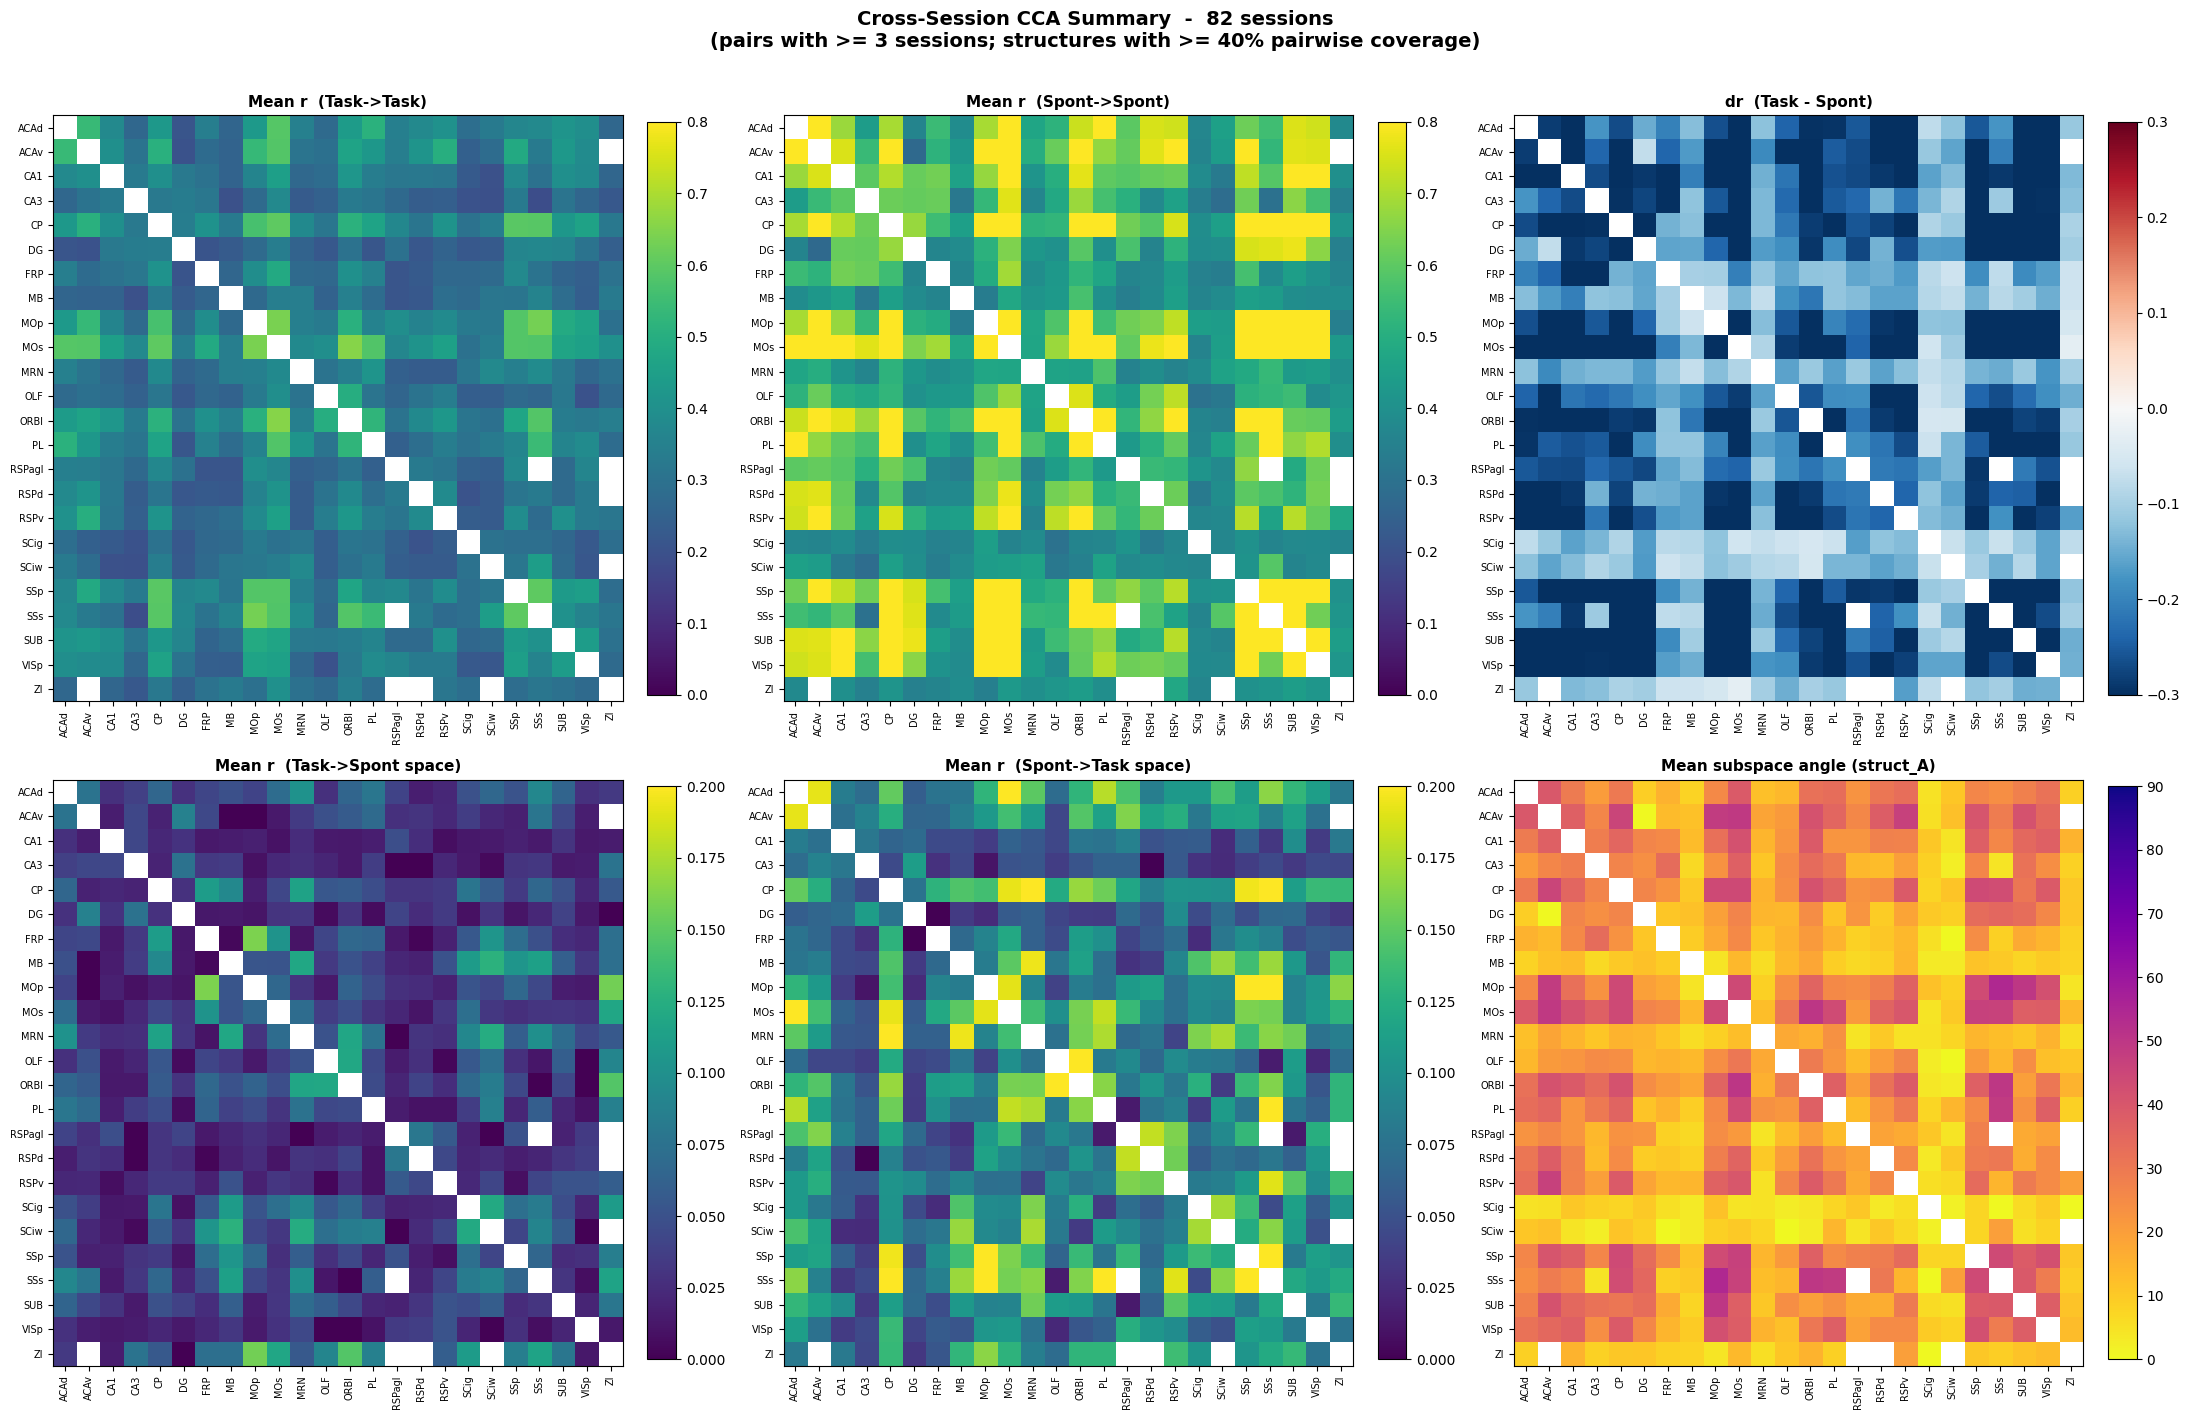

In [21]:
# ── Filter to well-covered structures ─────────────────────────────────────────
COVERAGE_THRESH = 0.40
plot_structs = filter_structs_by_coverage(
    cross_session_avg_filt, all_structs, COVERAGE_THRESH
)
print(f"Structures after coverage filter ({COVERAGE_THRESH:.0%}): "
      f"{len(plot_structs)} / {len(all_structs)}  ->  {plot_structs}")

# ── Build matrices ─────────────────────────────────────────────────────────────
mat_r_task     = build_matrix(cross_session_avg_filt, 'mean_r_task',          plot_structs)
mat_r_spont    = build_matrix(cross_session_avg_filt, 'mean_r_spont',         plot_structs)
mat_delta      = build_matrix(cross_session_avg_filt, 'delta_r_task_spont',   plot_structs)
mat_task_spont = build_matrix(cross_session_avg_filt, 'mean_r_task_in_spont', plot_structs)
mat_spont_task = build_matrix(cross_session_avg_filt, 'mean_r_spont_in_task', plot_structs)
mat_angle      = build_matrix(cross_session_avg_filt, 'mean_angle_A_deg',     plot_structs)
mat_n          = build_matrix(cross_session_avg_filt, 'n_sessions',           plot_structs)

n_sessions_total = all_summaries_df['session_id'].nunique()

# ── Main heatmap figure ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 14))
axes = axes.flatten()

plot_heatmap(axes[0], mat_r_task,     plot_structs, 'Mean r  (Task->Task)',              0,    0.8,   'viridis',  fig)
plot_heatmap(axes[1], mat_r_spont,    plot_structs, 'Mean r  (Spont->Spont)',            0,    0.8,   'viridis',  fig)
plot_heatmap(axes[2], mat_delta,      plot_structs, 'dr  (Task - Spont)',               -0.3,  0.3,  'RdBu_r',   fig)
plot_heatmap(axes[3], mat_task_spont, plot_structs, 'Mean r  (Task->Spont space)',       0,    0.2,   'viridis',  fig)
plot_heatmap(axes[4], mat_spont_task, plot_structs, 'Mean r  (Spont->Task space)',       0,    0.2,   'viridis',  fig)
plot_heatmap(axes[5], mat_angle,      plot_structs, 'Mean subspace angle (struct_A)',    0,   90,    'plasma_r', fig)

plt.suptitle(
    f'Cross-Session CCA Summary  -  {n_sessions_total} sessions\n'
    f'(pairs with >= {MIN_SESSIONS} sessions; structures with >= {COVERAGE_THRESH:.0%} pairwise coverage)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

In [17]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram


def cluster_matrix(mat, n_clusters=2, linkage='average'):
    """
    Cluster a symmetric matrix using sklearn AgglomerativeClustering.
    Uses Fisher z-transform internally for correlation-valued matrices.
    """
    # Fill NaNs with row medians for clustering
    mat_filled = mat.copy()
    for i in range(mat.shape[0]):
        row_median = np.nanmedian(mat[i, :])
        mat_filled[i, np.isnan(mat[i, :])] = row_median if not np.isnan(row_median) else 0

    clustering = AgglomerativeClustering(
        n_clusters=n_clusters,
        metric='euclidean',
        linkage=linkage,
        compute_distances=True,
    )
    clustering.fit(mat_filled)

    # Build scipy-compatible linkage matrix from the sklearn model
    counts = np.zeros(clustering.children_.shape[0])
    n_samples = len(clustering.labels_)
    for i, merge in enumerate(clustering.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count
    linkage_mat = np.column_stack(
        [clustering.children_, clustering.distances_, counts]
    ).astype(float)

    # Get leaf ordering from dendrogram
    dendro = dendrogram(linkage_mat, no_plot=True)
    order = np.array(dendro['leaves'])

    return order, linkage_mat, clustering.labels_


# Apply clustering to each matrix.
# For correlation matrices, apply Fisher z before clustering, then transform back.
corr_matrix_names = {'r_task', 'r_spont', 'delta', 'task_in_spont', 'spont_in_task'}

matrices = {
    'r_task': mat_r_task,
    'r_spont': mat_r_spont,
    'delta': mat_delta,
    'task_in_spont': mat_task_spont,
    'spont_in_task': mat_spont_task,
    'angle': mat_angle,
}

N_CLUSTERS = 2  # number of clusters for AgglomerativeClustering

clustering_results = {}
for name, mat in matrices.items():
    # Fisher z-transform correlation matrices before clustering
    if name in corr_matrix_names:
        mat_for_clustering = np.arctanh(np.clip(mat, -0.9999, 0.9999))
        # Preserve NaN positions
        mat_for_clustering[np.isnan(mat)] = np.nan
    else:
        mat_for_clustering = mat

    order, link_mat, labels = cluster_matrix(mat_for_clustering, n_clusters=N_CLUSTERS)
    clustering_results[name] = {
        'order': order,
        'linkage': link_mat,
        'clusters': labels,
        'ordered_structs': [plot_structs[i] for i in order],
    }
    print(f"{name}: {len(np.unique(labels))} clusters")

print(f"\nClustering complete (sklearn AgglomerativeClustering, n_clusters={N_CLUSTERS}).")

r_task: 2 clusters
r_spont: 2 clusters
delta: 2 clusters
task_in_spont: 2 clusters
spont_in_task: 2 clusters
angle: 2 clusters

Clustering complete (sklearn AgglomerativeClustering, n_clusters=2).


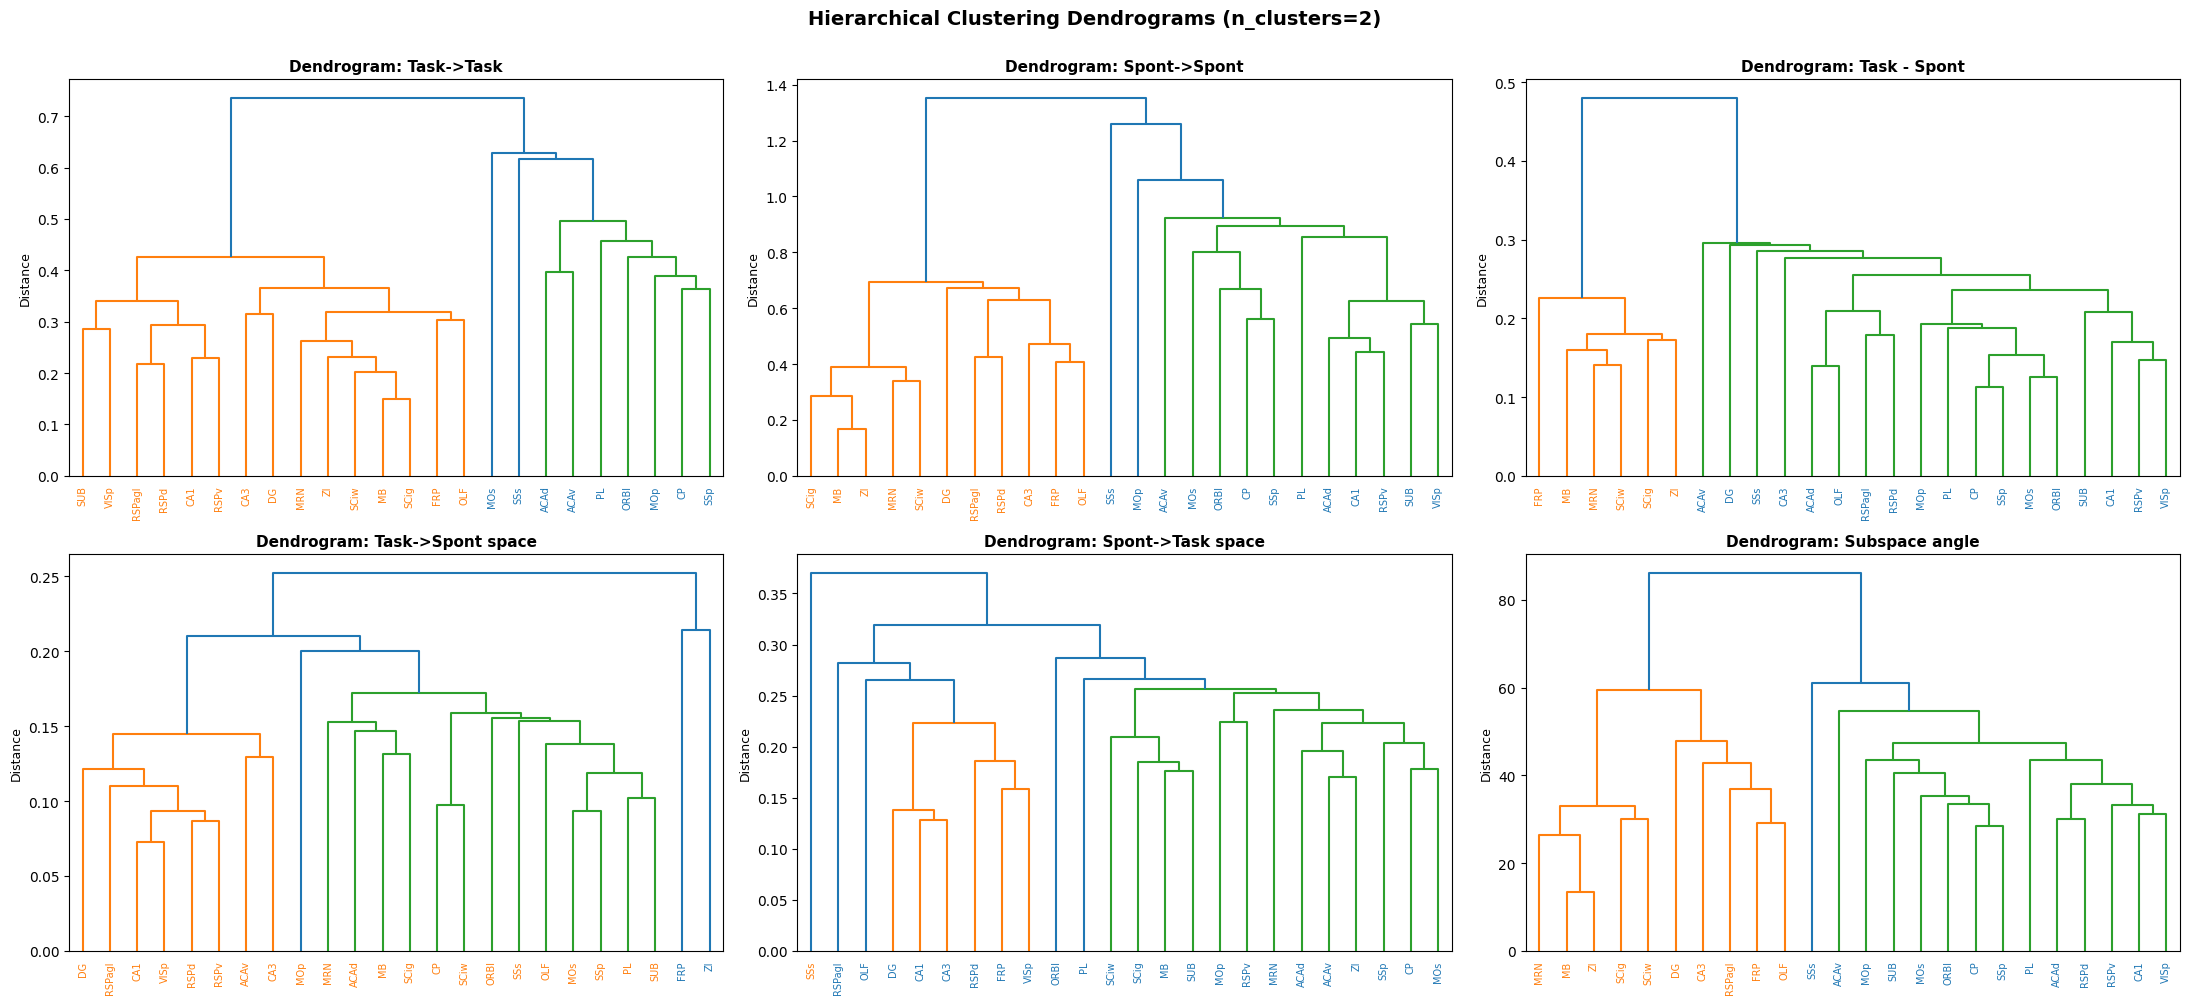

In [18]:
# Plot dendrograms for each clustering
fig_dendro, axes_dendro = plt.subplots(2, 3, figsize=(22, 10))
axes_dendro = axes_dendro.flatten()

titles = [
    'Task->Task',
    'Spont->Spont',
    'Task - Spont',
    'Task->Spont space',
    'Spont->Task space',
    'Subspace angle'
]

for idx, (name, title) in enumerate(zip(matrices.keys(), titles)):
    res = clustering_results[name]
    dendro_result = dendrogram(
        res['linkage'],
        ax=axes_dendro[idx],
        labels=np.array(plot_structs),
        leaf_rotation=90,
        leaf_font_size=7,
    )
    axes_dendro[idx].set_title(f'Dendrogram: {title}', fontsize=11, fontweight='bold')
    axes_dendro[idx].set_ylabel('Distance', fontsize=9)

    # Color-code cluster membership on tick labels
    cluster_colors = {0: 'tab:blue', 1: 'tab:orange', 2: 'tab:green', 3: 'tab:red'}
    ordered_labels = res['clusters'][res['order']]
    for tick_idx, tick in enumerate(axes_dendro[idx].get_xticklabels()):
        clust_id = ordered_labels[tick_idx]
        tick.set_color(cluster_colors.get(clust_id, 'black'))

plt.suptitle(f'Hierarchical Clustering Dendrograms (n_clusters={N_CLUSTERS})',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

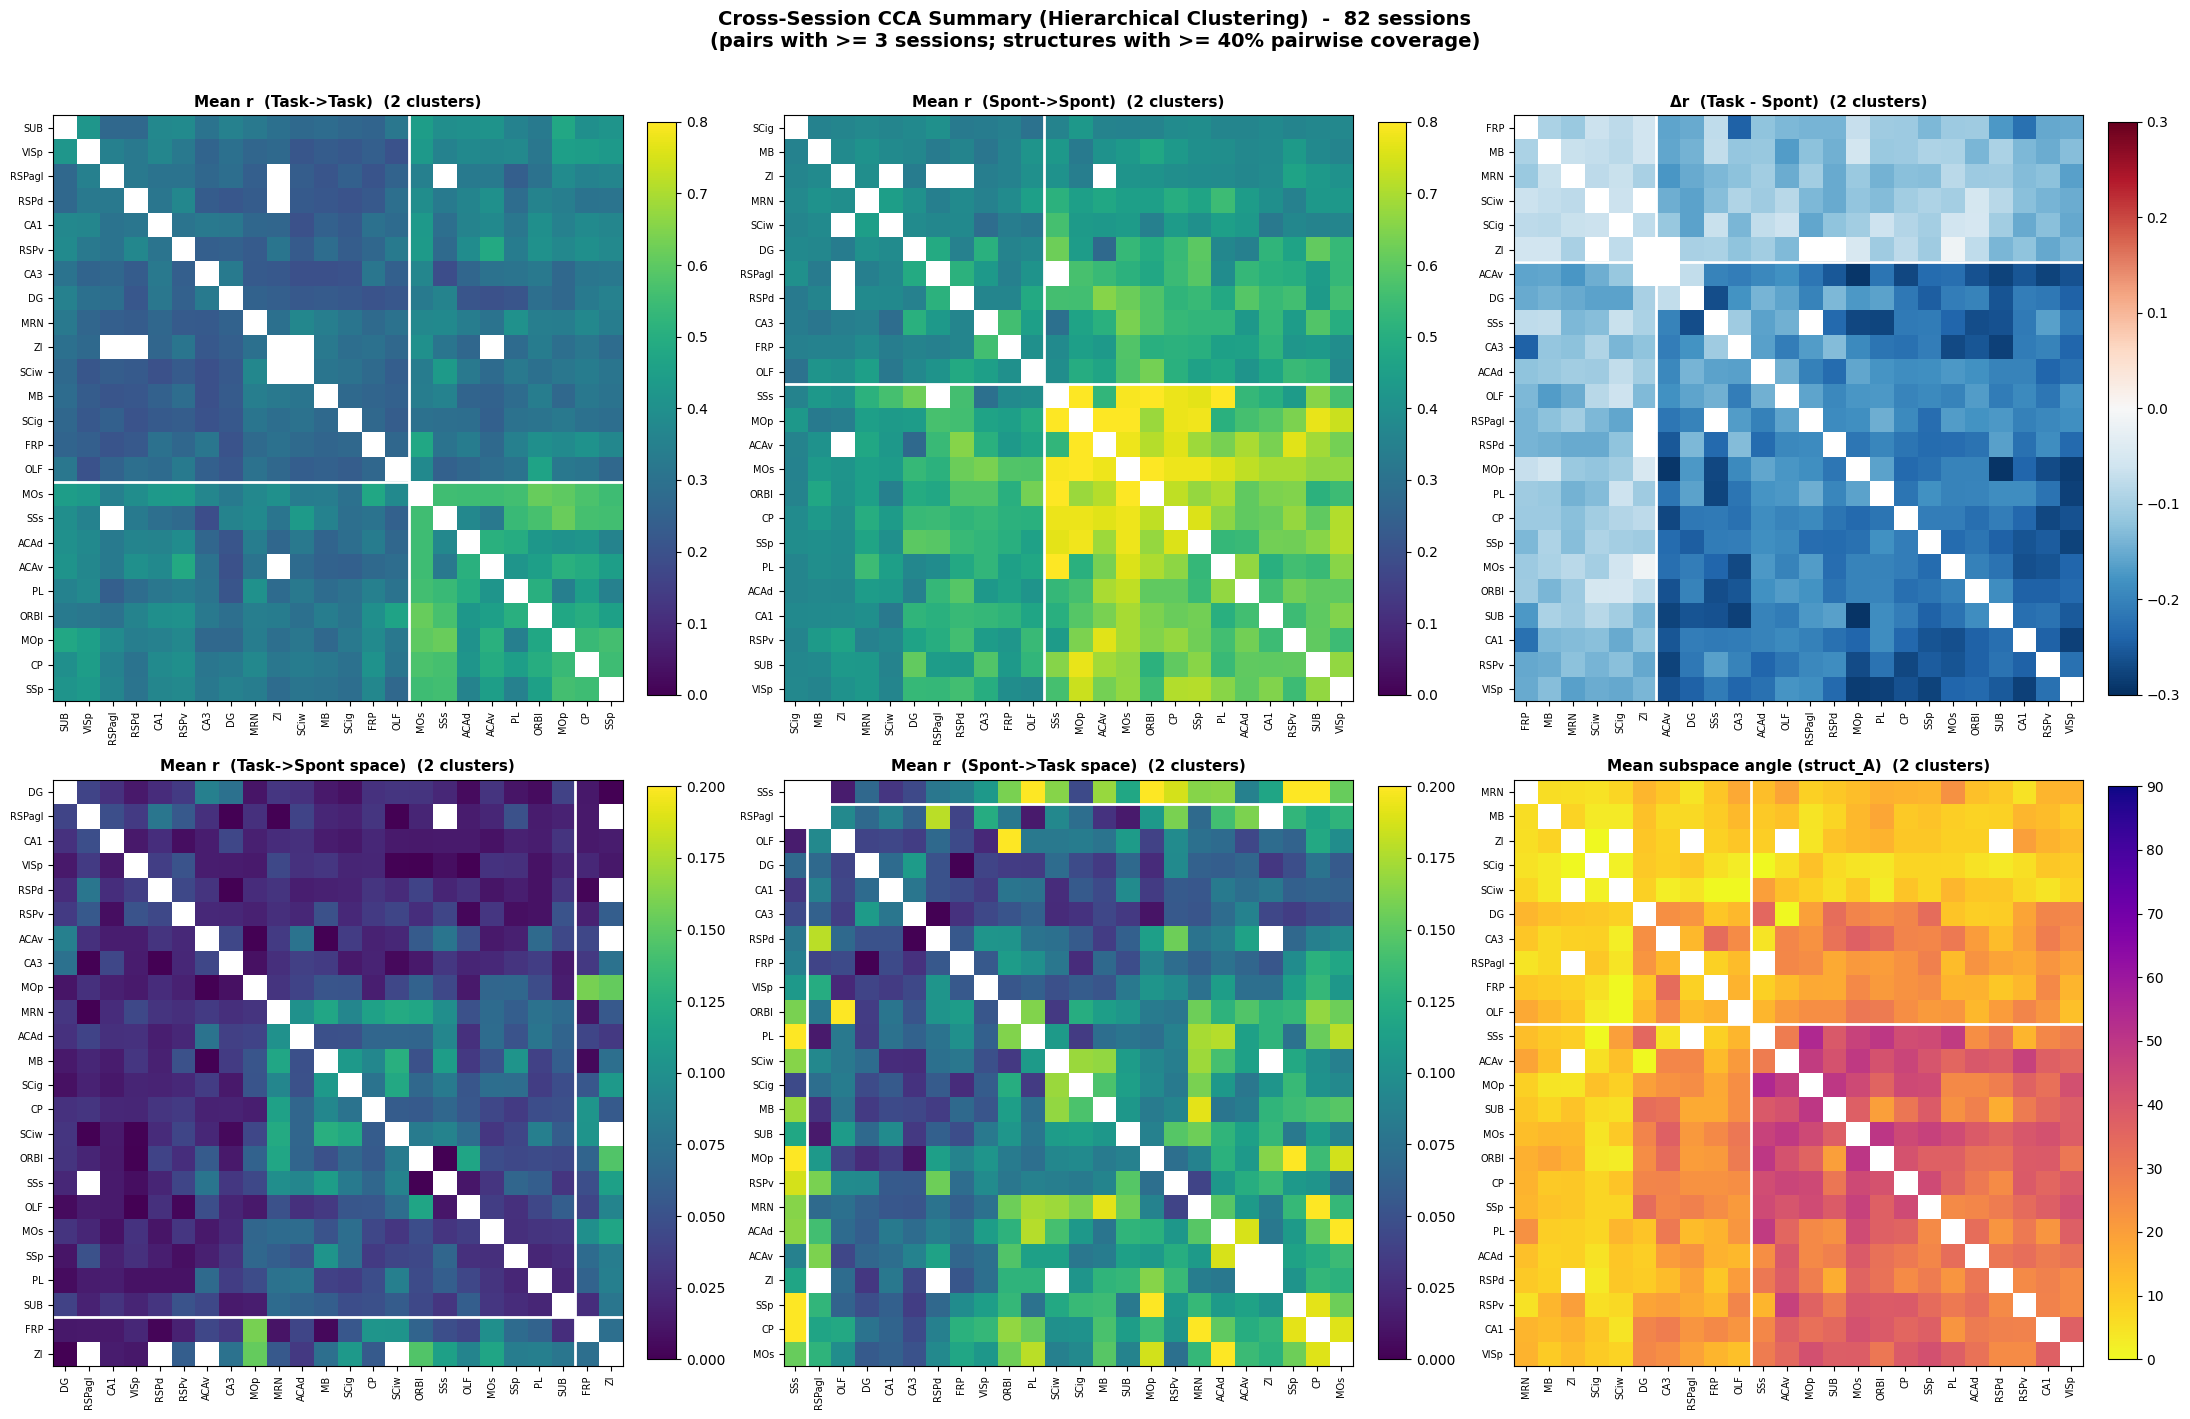


Clustered heatmaps plotted with cluster boundaries.


In [19]:
def plot_heatmap_clustered(ax, mat, structs, order, clusters, title, vmin, vmax, cmap, fig):
    """Plot heatmap with clustering order and cluster boundaries."""
    # Reorder matrix
    mat_ordered = mat[order][:, order]
    structs_ordered = [structs[i] for i in order]
    clusters_ordered = clusters[order]
    
    # Plot heatmap
    im = ax.imshow(mat_ordered, vmin=vmin, vmax=vmax, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(structs_ordered)))
    ax.set_yticks(range(len(structs_ordered)))
    ax.set_xticklabels(structs_ordered, rotation=90, fontsize=7)
    ax.set_yticklabels(structs_ordered, fontsize=7)
    ax.set_title(title, fontsize=11, fontweight='bold')
    
    # Add cluster boundaries
    cluster_changes = np.where(np.diff(clusters_ordered) != 0)[0] + 0.5
    for pos in cluster_changes:
        ax.axhline(y=pos, color='white', linewidth=2, linestyle='-')
        ax.axvline(x=pos, color='white', linewidth=2, linestyle='-')
    
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    return mat_ordered, structs_ordered


# Plot clustered heatmaps
fig_clust, axes_clust = plt.subplots(2, 3, figsize=(22, 14))
axes_clust = axes_clust.flatten()

plot_configs = [
    ('r_task',         'Mean r  (Task->Task)',           0,    0.8,  'viridis'),
    ('r_spont',        'Mean r  (Spont->Spont)',         0,    0.8,  'viridis'),
    ('delta',          'Δr  (Task - Spont)',            -0.3,  0.3,  'RdBu_r'),
    ('task_in_spont',  'Mean r  (Task->Spont space)',    0,    0.2,  'viridis'),
    ('spont_in_task',  'Mean r  (Spont->Task space)',    0,    0.2,  'viridis'),
    ('angle',          'Mean subspace angle (struct_A)', 0,   90,    'plasma_r'),
]

ordered_matrices = {}
for idx, (mat_name, title, vmin, vmax, cmap) in enumerate(plot_configs):
    res = clustering_results[mat_name]
    mat_ordered, structs_ordered = plot_heatmap_clustered(
        axes_clust[idx],
        matrices[mat_name],
        plot_structs,
        res['order'],
        res['clusters'],
        f'{title}  ({len(np.unique(res["clusters"]))} clusters)',
        vmin, vmax, cmap, fig_clust
    )
    ordered_matrices[mat_name] = {
        'matrix': mat_ordered,
        'structs': structs_ordered,
        'clusters': res['clusters'][res['order']]
    }

plt.suptitle(
    f'Cross-Session CCA Summary (Hierarchical Clustering)  -  {n_sessions_total} sessions\n'
    f'(pairs with >= {MIN_SESSIONS} sessions; structures with >= {COVERAGE_THRESH:.0%} pairwise coverage)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

print("\nClustered heatmaps plotted with cluster boundaries.")

In [20]:
# Save clustering orderings to CSV for future reference
import csv

ordering_save_path = output_dir / 'cca_clustering_orderings.csv'

with open(ordering_save_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['clustering_type', 'position', 'structure', 'cluster_id'])
    
    for name, res in clustering_results.items():
        ordered_clusters = res['clusters'][res['order']]
        for pos, (struct, clust) in enumerate(zip(res['ordered_structs'], ordered_clusters)):
            writer.writerow([name, pos, struct, clust])

print(f"Clustering orderings saved to: {ordering_save_path}")

# Also save a summary
summary_save_path = output_dir / 'cca_clustering_summary.txt'

with open(summary_save_path, 'w') as f:
    f.write("CCA Cross-Session Clustering Summary\n")
    f.write("=" * 60 + "\n\n")
    
    for name, res in clustering_results.items():
        f.write(f"\n{name.upper()}\n")
        f.write("-" * 40 + "\n")
        f.write(f"Number of clusters: {len(np.unique(res['clusters']))}\n")
        f.write(f"Ordered structures:\n")
        
        ordered_clusters = res['clusters'][res['order']]
        current_cluster = ordered_clusters[0]
        f.write(f"  Cluster {current_cluster}: ")
        cluster_members = []
        
        for struct, clust in zip(res['ordered_structs'], ordered_clusters):
            if clust != current_cluster:
                f.write(", ".join(cluster_members) + "\n")
                current_cluster = clust
                f.write(f"  Cluster {current_cluster}: ")
                cluster_members = [struct]
            else:
                cluster_members.append(struct)
        
        f.write(", ".join(cluster_members) + "\n")

print(f"Clustering summary saved to: {summary_save_path}")

Clustering orderings saved to: \\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CCA results\cca_clustering_orderings.csv
Clustering summary saved to: \\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CCA results\cca_clustering_summary.txt


## 9. Baseline-Normalized CCA (Cross-Session)

Run per-window CCA after removing baseline-related correlations, then aggregate across sessions.

| Window | Normalization | Rationale |
|--------|--------------|-----------|
| prestim | Subtract block mean | Remove slow context-dependent baseline shifts |
| context | Subtract block mean | Same as above |
| stim_vis | Subtract trial-wise prestim rate | Remove trial-by-trial baseline fluctuations |
| stim_aud | Subtract trial-wise prestim rate | Same as above |
| response | Subtract trial-wise prestim rate | Same as above |
| spontaneous | None | No task structure to correct for |

In [6]:
def run_session_cca_norm(session_id, output_dir,
                        min_units=MIN_UNITS, var_thresh=VAR_THRESH,
                        max_cca_comps=MAX_CCA_COMPS, n_boot=N_BOOT,
                        time_before=0.5, time_after=0.01, binsize=0.5):
    """
    Run baseline-normalized per-window CCA for one session.

    Returns
    -------
    'saved'    - completed and files written
    'exists'   - output files already present (skipped)
    'no_data'  - insufficient data (skipped)
    'error'    - unexpected exception (skipped)
    """
    from collections import OrderedDict

    comp_path = output_dir / f'cca_components_norm_{session_id}.parquet'
    summary_path = output_dir / f'cca_summary_norm_{session_id}.parquet'

    if comp_path.exists() and summary_path.exists():
        return 'exists'

    try:
        # ── Load session data ──────────────────────────────────────────────
        session_info = npc_lims.get_session_info(session_id)
        trials = data_utils.load_trials_or_units(session_info, 'trials', version='0.0.272')
        units = data_utils.load_trials_or_units(session_info, 'units', version='0.0.272')
        epochs = pd.read_parquet(
            npc_lims.get_cache_path(nwb_component='epochs', session_id=session_id, version='0.0.272')
        )

        # Check for pre-task Spontaneous epoch
        task_rows = epochs.query('script_name=="DynamicRouting1"')
        if len(task_rows) == 0:
            return 'no_data'
        task_index = task_rows.index[0]
        spont_epochs = epochs.query('script_name=="Spontaneous" and id<@task_index')
        if len(spont_epochs) == 0:
            return 'no_data'

        # Filter units
        units_filtered = units.query(
            'presence_ratio>=0.7 and '
            'isi_violations_ratio<=0.5 and '
            'amplitude_cutoff<=0.1 and '
            'activity_drift<=0.2 and '
            'firing_rate>=0.5 and '
            '~structure.isna() and ~location.isna()'
        ).sort_values(['electrode_group_name', 'peak_channel', 'unit_id'])

        if len(units_filtered) == 0:
            return 'no_data'

        # ── Build trial tensors ────────────────────────────────────────────
        trial_da = spike_utils.make_neuron_time_trials_tensor(
            units_filtered, trials, time_before, time_after, binsize
        )
        trial_da_ctx = spike_utils.make_neuron_time_trials_tensor(
            units_filtered, trials, time_before=0.2, time_after=0.001, bin_size=0.2
        )
        trial_da_stim = spike_utils.make_neuron_time_trials_tensor(
            units_filtered, trials, time_before=0, time_after=0.101, bin_size=0.1
        )
        trial_da_resp = spike_utils.make_neuron_time_trials_tensor(
            units_filtered, trials, time_before=-0.3, time_after=0.501, bin_size=0.2
        )

        # Spontaneous trials
        import lazynwb
        nwb_path = 's3://aind-scratch-data/dynamic-routing/cache/nwb/v0.0.272/{sid}.nwb'
        rewards = lazynwb.get_df(
            nwb_path.format(sid=session_id),
            'processing/behavior/rewards', as_polars=False
        )

        spont_trials_dict = {'start_time': [], 'epoch_idx': [], 'epoch_name': [], 'is_rewarded': []}
        for rr, row in spont_epochs.iterrows():
            spont_start, spont_end = row['start_time'], row['stop_time']
            sampleITIs = generate_DR_ITI(n_samples=1000, is_templeton=False)
            cum_ITIs = np.cumsum(sampleITIs)
            valid_starts = spont_start + cum_ITIs[cum_ITIs + spont_start < spont_end]
            is_rew = np.zeros(len(valid_starts), dtype=bool)

            reward_times = rewards.query(
                'timestamps>=@spont_start and timestamps<=@spont_end'
            )['timestamps'].to_numpy()
            if len(reward_times) > 0:
                for rt in reward_times:
                    keep = np.abs(valid_starts - rt) > 5.5
                    valid_starts, is_rew = valid_starts[keep], is_rew[keep]
                valid_starts = np.concatenate([valid_starts, reward_times])
                is_rew = np.concatenate([is_rew, np.ones(len(reward_times), dtype=bool)])

            spont_trials_dict['start_time'].append(valid_starts)
            spont_trials_dict['epoch_idx'].append(np.repeat(rr, len(valid_starts)))
            spont_trials_dict['epoch_name'].append(np.repeat(row['script_name'], len(valid_starts)))
            spont_trials_dict['is_rewarded'].append(is_rew)

        for k in spont_trials_dict:
            spont_trials_dict[k] = np.concatenate(spont_trials_dict[k])
        spont_trials_df = (
            pd.DataFrame(spont_trials_dict)
            .sort_values('start_time').reset_index(drop=True)
        )
        if len(spont_trials_df) == 0:
            return 'no_data'

        spont_trial_da = spike_utils.make_neuron_time_trials_tensor(
            units_filtered, spont_trials_df, time_before, time_after, binsize,
            event_name='start_time'
        )

        # ── Per-structure: baseline normalization + PCA ────────────────────
        unit_counts = units_filtered.groupby('structure')['unit_id'].nunique()
        qualified_structures = sorted(unit_counts[unit_counts >= min_units].index.tolist())
        if len(qualified_structures) < 2:
            return 'no_data'

        # Block IDs for block-mean subtraction
        block_ids = trials['rewarded_modality'].ne(trials['rewarded_modality'].shift()).cumsum().values
        time_idx = 0

        struct_data_norm = {}
        for struct in qualified_structures:
            uid = units_filtered[units_filtered['structure'] == struct]['unit_id'].unique()

            A_prestim = trial_da.sel(unit_id=uid).data[:, time_idx, :].T
            A_spont = spont_trial_da.sel(unit_id=uid).data[:, time_idx, :].T
            A_ctx = trial_da_ctx.sel(unit_id=uid).data[:, time_idx, :].T
            A_stim = trial_da_stim.sel(unit_id=uid).data[:, time_idx, :].T
            A_resp = trial_da_resp.sel(unit_id=uid).data[:, time_idx, :].T

            # Block-mean subtraction (prestim & context)
            prestim_norm = A_prestim.copy()
            ctx_norm = A_ctx.copy()
            for b in np.unique(block_ids):
                bmask = block_ids == b
                prestim_norm[bmask] -= A_prestim[bmask].mean(axis=0, keepdims=True)
                ctx_norm[bmask] -= A_ctx[bmask].mean(axis=0, keepdims=True)

            # Trial-wise prestim subtraction (stim & response)
            stim_norm = A_stim - A_prestim
            resp_norm = A_resp - A_prestim

            # Pooled z-score & PCA
            A_all_raw = np.vstack([prestim_norm, A_spont, ctx_norm, stim_norm, resp_norm])
            scaler = StandardScaler().fit(A_all_raw)

            prestim_z = scaler.transform(prestim_norm)
            spont_z = scaler.transform(A_spont)
            ctx_z = scaler.transform(ctx_norm)
            stim_z = scaler.transform(stim_norm)
            resp_z = scaler.transform(resp_norm)

            A_all_z = np.vstack([prestim_z, spont_z, ctx_z, stim_z, resp_z])
            pca, n_pc, _ = pca_fit_keep(A_all_z, var_thresh=var_thresh)

            struct_data_norm[struct] = {
                'pca': pca, 'n_pc': n_pc, 'n_units': len(uid),
                'task_pca': pca.transform(prestim_z),
                'spont_pca': pca.transform(spont_z),
                'context_pca': pca.transform(ctx_z),
                'stim_pca': pca.transform(stim_z),
                'resp_pca': pca.transform(resp_z),
            }

        # ── Define CCA windows (session-specific masks) ────────────────────
        vis_mask = trials['is_vis_stim'].values.astype(bool)
        aud_mask = trials['is_aud_stim'].values.astype(bool)

        cca_windows = OrderedDict([
            ('prestim',     ('task_pca',    None)),
            ('context',     ('context_pca', None)),
            ('stim_vis',    ('stim_pca',    vis_mask)),
            ('stim_aud',    ('stim_pca',    aud_mask)),
            ('response',    ('resp_pca',    None)),
            ('spontaneous', ('spont_pca',   None)),
        ])

        # ── Run CCA for all pairs × windows ───────────────────────────────
        all_records = []
        for sA, sB in combinations(qualified_structures, 2):
            for win_name, (pca_key, trial_mask) in cca_windows.items():
                dA, dB = struct_data_norm[sA], struct_data_norm[sB]
                A, B = dA[pca_key], dB[pca_key]
                if trial_mask is not None and pca_key != 'spont_pca':
                    mask = np.asarray(trial_mask, dtype=bool)
                    A, B = A[mask], B[mask]

                A_m, B_m, d = match_dims(A, B)
                k = min(max_cca_comps, d, A_m.shape[0] - 1, B_m.shape[0] - 1)
                if k < 1:
                    continue
                try:
                    cca_obj, A_c, B_c = run_cca(A_m, B_m, n_components=k)
                except Exception:
                    continue

                r = canonical_corrs(A_c, B_c)
                ci = np.full((2, k), np.nan)
                if n_boot > 0:
                    boot = bootstrap_corrs(A_m, B_m, n_components=k, n_boot=n_boot)
                    ci = np.percentile(boot, [2.5, 97.5], axis=0)

                for i in range(k):
                    all_records.append({
                        'struct_A': sA, 'struct_B': sB,
                        'time_window': win_name,
                        'component': i + 1, 'n_cca_comps': k,
                        'r': r[i], 'r_ci_lo': ci[0, i], 'r_ci_hi': ci[1, i],
                        'n_pca_A': dA['n_pc'], 'n_pca_B': dB['n_pc'],
                        'n_units_A': dA['n_units'], 'n_units_B': dB['n_units'],
                        'n_trials': A_m.shape[0],
                    })

        if len(all_records) == 0:
            return 'no_data'

        # ── Build & save DataFrames ────────────────────────────────────────
        col_order = [
            'session_id', 'struct_A', 'struct_B', 'time_window',
            'n_units_A', 'n_units_B', 'n_pca_A', 'n_pca_B',
            'n_trials', 'n_cca_comps', 'component',
            'r', 'r_ci_lo', 'r_ci_hi',
        ]
        cca_norm_df = (
            pd.DataFrame(all_records)
            .assign(session_id=session_id)
            [col_order]
            .sort_values(['struct_A', 'struct_B', 'time_window', 'component'])
            .reset_index(drop=True)
        )
        summary_norm_df = (
            cca_norm_df
            .groupby(['session_id', 'struct_A', 'struct_B', 'time_window',
                      'n_units_A', 'n_units_B', 'n_pca_A', 'n_pca_B',
                      'n_trials', 'n_cca_comps'], sort=False)
            .agg(mean_r=('r', 'mean'), r_comp1=('r', 'first'))
            .sort_values('mean_r', ascending=False)
            .reset_index()
        )

        cca_norm_df.to_parquet(comp_path, index=False)
        summary_norm_df.to_parquet(summary_path, index=False)
        return 'saved'

    except Exception:
        traceback.print_exc()
        return 'error'


print("run_session_cca_norm() defined.")

run_session_cca_norm() defined.


In [7]:
# ── Batch run baseline-normalized CCA over all sessions ────────────────────────
status_counts_norm = {'saved': 0, 'exists': 0, 'no_data': 0, 'error': 0}
t0 = time.time()

for s_idx, sid in enumerate(dr_session_list):
    status = run_session_cca_norm(sid, output_dir)
    status_counts_norm[status] += 1
    tag = {'saved': '✓', 'exists': '–', 'no_data': 'skip', 'error': 'ERR'}[status]
    if status in ('saved', 'error') or (s_idx + 1) % 25 == 0:
        print(f"[{s_idx+1:4d}/{len(dr_session_list)}]  {sid}  {tag}  "
              f"({time.time()-t0:.0f}s elapsed)")

print(f"\nDone.  {status_counts_norm}")

620263_2022-07-26 cached trials loaded
620263_2022-07-26 cached units loaded
620263_2022-07-27 cached trials loaded
620263_2022-07-27 cached units loaded
620264_2022-08-02 cached trials loaded
620264_2022-08-02 cached units loaded
626791_2022-08-15 cached trials loaded
626791_2022-08-15 cached units loaded
626791_2022-08-16 cached trials loaded
626791_2022-08-16 cached units loaded
626791_2022-08-17 cached trials loaded
626791_2022-08-17 cached units loaded
628801_2022-09-19 cached trials loaded
628801_2022-09-19 cached units loaded
636397_2022-09-26 cached trials loaded
636397_2022-09-26 cached units loaded
636397_2022-09-27 cached trials loaded
636397_2022-09-27 cached units loaded
644547_2022-12-05 cached trials loaded
644547_2022-12-05 cached units loaded
644547_2022-12-06 cached trials loaded
644547_2022-12-06 cached units loaded
646318_2023-01-17 cached trials loaded
646318_2023-01-17 cached units loaded
646318_2023-01-18 cached trials loaded
646318_2023-01-18 cached units loaded

c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


[  38/178]  668759_2023-07-13  ✓  (726s elapsed)
670181_2023-07-18 cached trials loaded
670181_2023-07-18 cached units loaded


c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: Con

[  39/178]  670181_2023-07-18  ✓  (1034s elapsed)
670180_2023-07-26 cached trials loaded
670180_2023-07-26 cached units loaded


...

[ 176/178]  759434_2025-02-05  ✓  (32010s elapsed)
759434_2025-02-06 cached trials loaded
759434_2025-02-06 cached units loaded


c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


[ 177/178]  759434_2025-02-06  ✓  (32090s elapsed)
759434_2025-02-07 cached trials loaded
759434_2025-02-07 cached units loaded


c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


[ 178/178]  759434_2025-02-07  ✓  (32251s elapsed)

Done.  {'saved': 140, 'exists': 0, 'no_data': 38, 'error': 0}


In [30]:
# ── Load & aggregate normalized CCA results ────────────────────────────────────
norm_summary_files = sorted(output_dir.glob('cca_summary_norm_*.parquet'))
print(f"Found {len(norm_summary_files)} normalized summary files")

all_norm_summaries = []
for f in norm_summary_files:
    try:
        all_norm_summaries.append(pd.read_parquet(f))
    except Exception as e:
        print(f"  Could not load {f.name}: {e}")

all_norm_summaries_df = pd.concat(all_norm_summaries, ignore_index=True)
all_norm_summaries_df = all_norm_summaries_df.query('session_id in @dr_session_list_good')

print(f"Total rows: {len(all_norm_summaries_df)}")
print(f"Sessions: {all_norm_summaries_df['session_id'].nunique()}")
print(f"Windows: {all_norm_summaries_df['time_window'].unique().tolist()}")

Found 140 normalized summary files
Total rows: 82998
Sessions: 82
Windows: ['spontaneous', 'stim_vis', 'stim_aud', 'prestim', 'response', 'context']


In [31]:
# ── Cross-session average: normalized CCA (Fisher z-transform) ─────────────────
corr_cols_norm = ['mean_r']

MIN_SESSIONS = 3

# Symmetrise
fwd_n = all_norm_summaries_df[['session_id', 'struct_A', 'struct_B', 'time_window', 'mean_r', 'r_comp1']].copy()
rev_n = all_norm_summaries_df[['session_id', 'struct_B', 'struct_A', 'time_window', 'mean_r', 'r_comp1']].copy()
rev_n.columns = ['session_id', 'struct_A', 'struct_B', 'time_window', 'mean_r', 'r_comp1']
both_n = pd.concat([fwd_n, rev_n], ignore_index=True)

both_n['mean_r_z'] = np.arctanh(np.clip(both_n['mean_r'], -0.9999, 0.9999))
both_n['r_comp1_z'] = np.arctanh(np.clip(both_n['r_comp1'], -0.9999, 0.9999))

cross_session_norm = (
    both_n
    .groupby(['struct_A', 'struct_B', 'time_window'], sort=True)
    .agg(
        mean_r_z=('mean_r_z', 'mean'),
        r_comp1_z=('r_comp1_z', 'mean'),
        n_sessions=('session_id', 'nunique'),
    )
    .reset_index()
)
cross_session_norm['mean_r'] = np.tanh(cross_session_norm['mean_r_z'])
cross_session_norm['r_comp1'] = np.tanh(cross_session_norm['r_comp1_z'])
cross_session_norm.drop(columns=['mean_r_z', 'r_comp1_z'], inplace=True)

cross_session_norm_filt = cross_session_norm[cross_session_norm['n_sessions'] >= MIN_SESSIONS]

print(f"Cross-session normalized averages: {len(cross_session_norm_filt)} rows")
print(f"\nMean r by window (across all pairs):")
print(cross_session_norm_filt.groupby('time_window')['mean_r'].mean().round(3).to_string())

Cross-session normalized averages: 19308 rows

Mean r by window (across all pairs):
time_window
context        0.240
prestim        0.268
response       0.276
spontaneous    0.512
stim_aud       0.301
stim_vis       0.298


In [32]:
# ── Compare raw vs normalized CCA across sessions ─────────────────────────────
# Also load raw per-window summaries (from the §5 batch run).
# The raw results use the same file naming: cca_summary_{session_id}.parquet

COVERAGE_THRESH = 0.40

# Load raw cross-session results for comparison (already built above in §7)
# all_summaries_df should already exist from earlier cells.
# Build per-window averages for raw results too.
fwd_r = all_summaries_df[['session_id', 'struct_A', 'struct_B']].copy()
# The raw batch (§5) only has task/spont, not per-window — check if time_window exists
if 'time_window' not in all_summaries_df.columns:
    print("Raw results do not have per-window CCA (only task vs spont).")
    print("Comparison will use normalized results only.")
    HAS_RAW_PERWINDOW = False
else:
    HAS_RAW_PERWINDOW = True

# Load raw per-window component files (if they exist from single-session notebook saves)
raw_perwindow_files = sorted(output_dir.glob('cca_components_*.parquet'))
# Exclude norm files
raw_perwindow_files = [f for f in raw_perwindow_files if '_norm_' not in f.name]

if raw_perwindow_files:
    raw_pw_dfs = []
    for f in raw_perwindow_files:
        try:
            df = pd.read_parquet(f)
            if 'time_window' in df.columns:
                raw_pw_dfs.append(df)
        except Exception:
            pass

    if raw_pw_dfs:
        raw_pw_all = pd.concat(raw_pw_dfs, ignore_index=True)
        raw_pw_all = raw_pw_all.query('session_id in @dr_session_list_good')
        HAS_RAW_PERWINDOW = len(raw_pw_all) > 0
        if HAS_RAW_PERWINDOW:
            raw_pw_summary = (
                raw_pw_all
                .groupby(['session_id', 'struct_A', 'struct_B', 'time_window'])
                .agg(mean_r=('r', 'mean'), r_comp1=('r', 'first'))
                .reset_index()
            )
            print(f"Raw per-window results: {raw_pw_summary['session_id'].nunique()} sessions")
    else:
        HAS_RAW_PERWINDOW = False

if not HAS_RAW_PERWINDOW:
    print("No raw per-window CCA files found — skipping raw vs normalized comparison.")
else:
    # Compare mean r by window
    raw_means = raw_pw_summary.groupby('time_window')['mean_r'].mean()
    norm_means = all_norm_summaries_df.groupby('time_window')['mean_r'].mean()
    comparison = pd.DataFrame({
        'raw': raw_means, 'normalized': norm_means,
        'delta': norm_means - raw_means
    }).round(3)
    print("\nMean r by window (raw vs normalized, averaged over pairs & sessions):")
    print(comparison.to_string())

No raw per-window CCA files found — skipping raw vs normalized comparison.


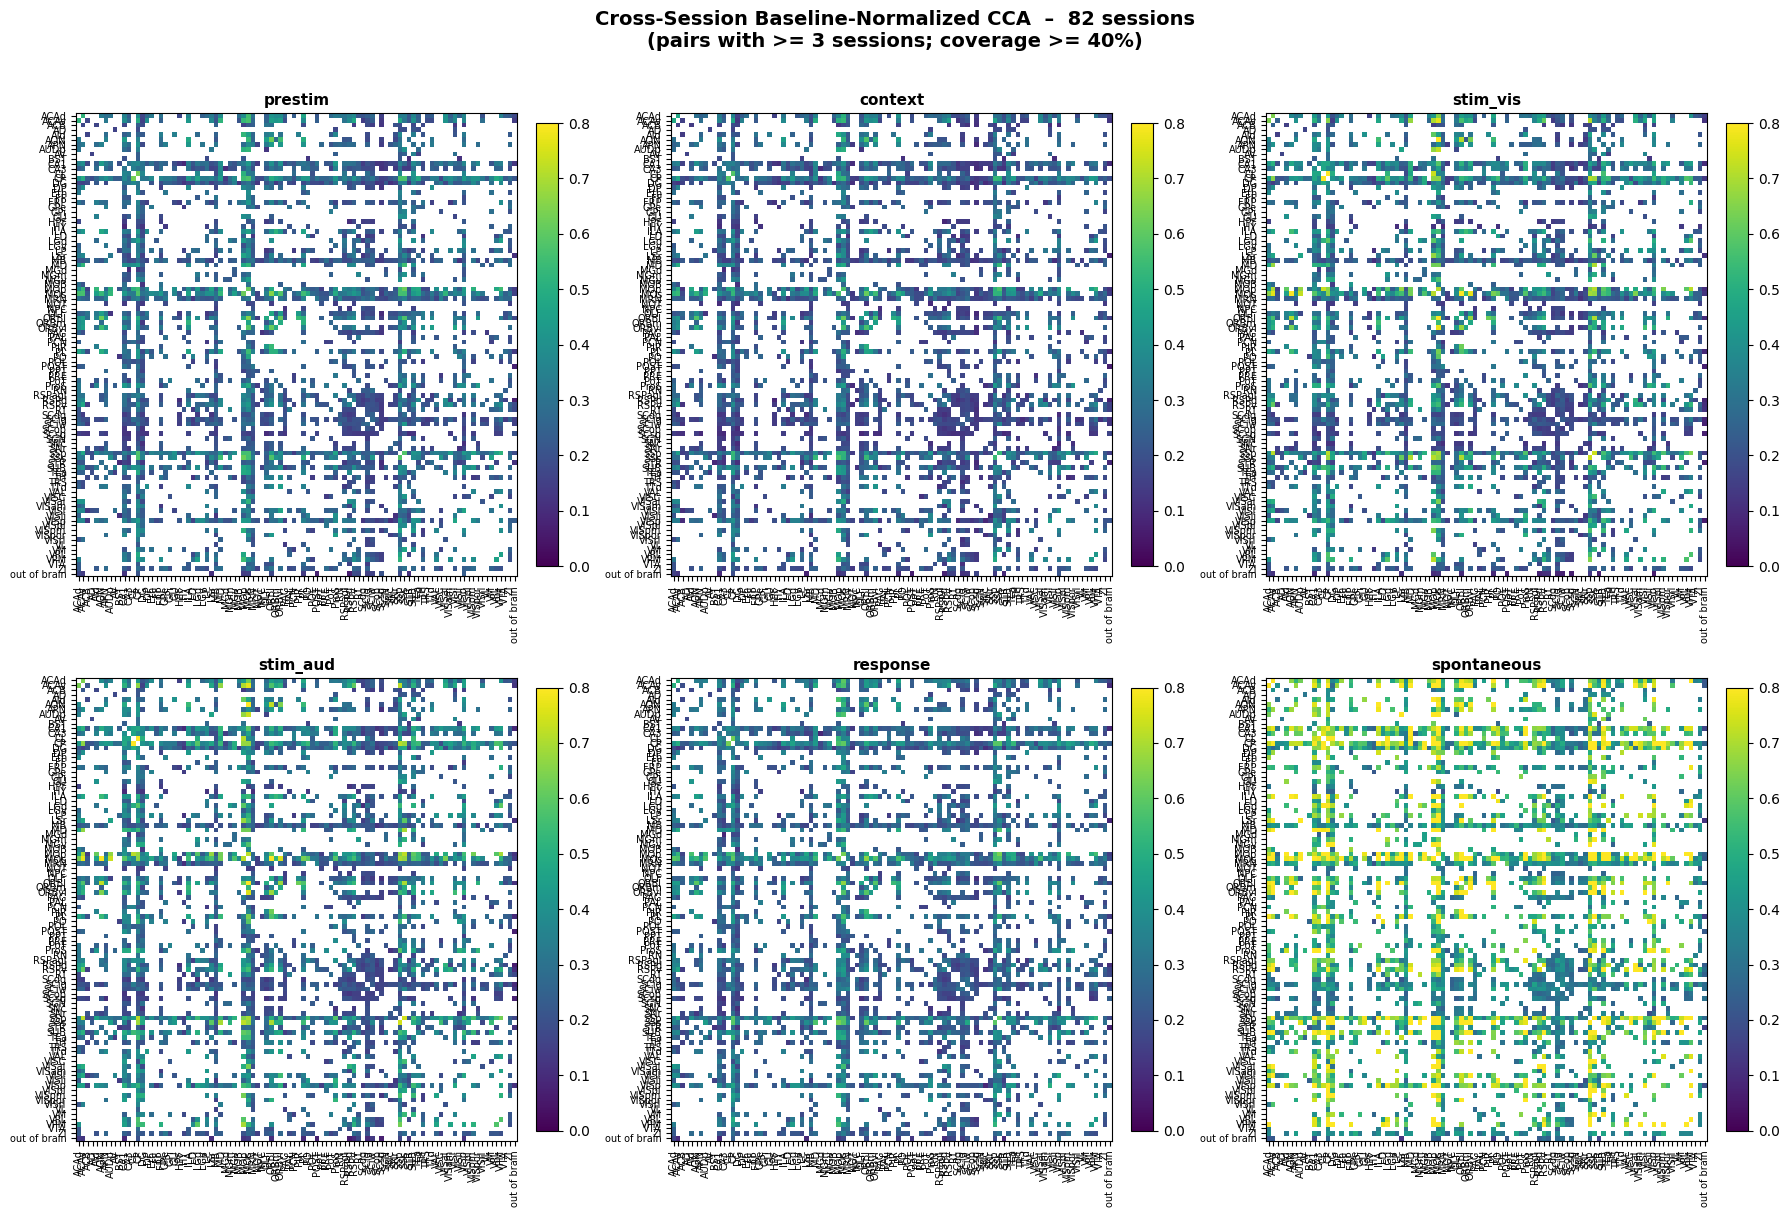

In [33]:
# ── Heatmaps: cross-session normalized CCA per time window ─────────────────────
COVERAGE_THRESH = 0.40
norm_plot_structs = filter_structs_by_coverage(
    cross_session_norm_filt, 
    sorted(set(cross_session_norm_filt['struct_A']) | set(cross_session_norm_filt['struct_B'])),
    COVERAGE_THRESH
)

window_names_norm = ['prestim', 'context', 'stim_vis', 'stim_aud', 'response', 'spontaneous']
n_win_norm = len(window_names_norm)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, win_name in enumerate(window_names_norm):
    sub = cross_session_norm_filt[cross_session_norm_filt['time_window'] == win_name]
    mat = build_matrix(sub, 'mean_r', norm_plot_structs)
    plot_heatmap(axes[idx], mat, norm_plot_structs, 
                 f'{win_name}', 0, 0.8, 'viridis', fig)

n_sess_norm = all_norm_summaries_df['session_id'].nunique()
plt.suptitle(
    f'Cross-Session Baseline-Normalized CCA  –  {n_sess_norm} sessions\n'
    f'(pairs with >= {MIN_SESSIONS} sessions; coverage >= {COVERAGE_THRESH:.0%})',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

In [34]:
# ── Bar chart: raw vs normalized mean r per window (cross-session) ─────────────
if HAS_RAW_PERWINDOW:
    # Build cross-session averages for raw per-window data
    fwd_raw = raw_pw_summary[['session_id', 'struct_A', 'struct_B', 'time_window', 'mean_r']].copy()
    rev_raw = raw_pw_summary[['session_id', 'struct_B', 'struct_A', 'time_window', 'mean_r']].copy()
    rev_raw.columns = ['session_id', 'struct_A', 'struct_B', 'time_window', 'mean_r']
    both_raw = pd.concat([fwd_raw, rev_raw], ignore_index=True)
    both_raw['mean_r_z'] = np.arctanh(np.clip(both_raw['mean_r'], -0.9999, 0.9999))

    cross_raw_bywin = (
        both_raw.groupby('time_window')['mean_r_z'].mean()
        .apply(np.tanh)
    )
    cross_norm_bywin = (
        both_n.groupby('time_window')['mean_r_z'].mean()
        .apply(np.tanh)
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(window_names_norm))
    w = 0.35
    raw_vals = [cross_raw_bywin.get(wn, 0) for wn in window_names_norm]
    norm_vals = [cross_norm_bywin.get(wn, 0) for wn in window_names_norm]

    ax.bar(x - w/2, raw_vals, w, label='Raw', color='steelblue', alpha=0.8)
    ax.bar(x + w/2, norm_vals, w, label='Normalized', color='coral', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(window_names_norm, rotation=45, ha='right', fontsize=10)
    ax.set_ylabel('Mean canonical correlation (Fisher z-avg)', fontsize=11)
    ax.set_title('Raw vs Baseline-Normalized CCA (Cross-Session Average)', 
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping raw vs normalized bar chart (no raw per-window data).")

Skipping raw vs normalized bar chart (no raw per-window data).


## 10. Coding Axis – CCA Alignment (Cross-Session)

For each brain area, compute 1-D coding axes (via LDA) for four task variables,
then measure the angle between each coding axis and the first CCA canonical weight vector.

**Task variables & time windows:**
1. **rewarded_modality** – visual vs auditory context (context window, −0.2–0 s)
2. **vis_stim_discrim** – vis1 vs vis2 (stimulus window, unrewarded blocks, no-response)
3. **aud_stim_discrim** – sound1 vs sound2 (stimulus window, unrewarded blocks, no-response)
4. **is_response** – lick vs no-lick (response window, 0.3–0.5 s)

Small angles indicate the inter-area CCA dimension is aligned with that task variable's coding axis.

In [35]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score


def angle_between_vectors(u, v, degrees=True):
    """Angle between two 1-D vectors (0–90°). Ignores sign ambiguity."""
    cos = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v) + 1e-12)
    cos = np.clip(cos, -1.0, 1.0)
    angle = np.arccos(np.abs(cos))
    return np.degrees(angle) if degrees else angle


def fit_coding_axis(X, labels, min_per_class=15):
    """
    Fit a 1-D LDA and return the unit-length weight vector in feature space.
    Returns (axis, accuracy, n_per_class). axis is None if insufficient data.
    """
    mask = ~pd.isna(labels)
    X, labels = X[mask], np.asarray(labels)[mask]
    classes, counts = np.unique(labels, return_counts=True)
    if len(classes) < 2 or np.any(counts < min_per_class):
        return None, np.nan, dict(zip(classes, counts))

    lda = LinearDiscriminantAnalysis(n_components=1, solver='svd')
    lda.fit(X, labels)
    axis = lda.coef_.flatten()
    axis = axis / (np.linalg.norm(axis) + 1e-12)

    acc = cross_val_score(
        LinearDiscriminantAnalysis(solver='svd'), X, labels,
        cv=min(5, min(counts)), scoring='accuracy'
    ).mean()

    return axis, acc, dict(zip(classes, counts))


print("angle_between_vectors() and fit_coding_axis() defined.")

angle_between_vectors() and fit_coding_axis() defined.


In [36]:
def run_session_coding_angles(session_id, output_dir,
                              min_units=MIN_UNITS, var_thresh=VAR_THRESH,
                              max_cca_comps=MAX_CCA_COMPS, n_perm=10,
                              time_before=0.5, time_after=0.01, binsize=0.5):
    """
    Compute coding-axis–CCA alignment for one session.

    For each area pair and each task variable, measures the angle between the
    variable's LDA coding axis and the first CCA canonical weight vector.
    Includes a label-shuffle null distribution.

    Returns
    -------
    'saved'    - completed and files written
    'exists'   - output files already present (skipped)
    'no_data'  - insufficient data (skipped)
    'error'    - unexpected exception (skipped)
    """
    from collections import OrderedDict

    angles_path = output_dir / f'cca_coding_angles_{session_id}.parquet'
    best_path = output_dir / f'cca_best_aligned_{session_id}.parquet'

    if angles_path.exists() and best_path.exists():
        return 'exists'

    try:
        # ── Load session data ──────────────────────────────────────────────
        session_info = npc_lims.get_session_info(session_id)
        trials = data_utils.load_trials_or_units(session_info, 'trials', version='0.0.272')
        units = data_utils.load_trials_or_units(session_info, 'units', version='0.0.272')
        epochs = pd.read_parquet(
            npc_lims.get_cache_path(nwb_component='epochs', session_id=session_id, version='0.0.272')
        )

        task_rows = epochs.query('script_name=="DynamicRouting1"')
        if len(task_rows) == 0:
            return 'no_data'
        task_index = task_rows.index[0]
        spont_epochs = epochs.query('script_name=="Spontaneous" and id<@task_index')
        if len(spont_epochs) == 0:
            return 'no_data'

        units_filtered = units.query(
            'presence_ratio>=0.7 and '
            'isi_violations_ratio<=0.5 and '
            'amplitude_cutoff<=0.1 and '
            'activity_drift<=0.2 and '
            'firing_rate>=0.5 and '
            '~structure.isna() and ~location.isna()'
        ).sort_values(['electrode_group_name', 'peak_channel', 'unit_id'])

        if len(units_filtered) == 0:
            return 'no_data'

        # ── Build trial tensors ────────────────────────────────────────────
        trial_da = spike_utils.make_neuron_time_trials_tensor(
            units_filtered, trials, time_before, time_after, binsize
        )
        trial_da_ctx = spike_utils.make_neuron_time_trials_tensor(
            units_filtered, trials, time_before=0.2, time_after=0.001, bin_size=0.2
        )
        trial_da_stim = spike_utils.make_neuron_time_trials_tensor(
            units_filtered, trials, time_before=0, time_after=0.101, bin_size=0.1
        )
        trial_da_resp = spike_utils.make_neuron_time_trials_tensor(
            units_filtered, trials, time_before=-0.3, time_after=0.501, bin_size=0.2
        )

        # Spontaneous trials
        import lazynwb
        nwb_path = 's3://aind-scratch-data/dynamic-routing/cache/nwb/v0.0.272/{sid}.nwb'
        rewards = lazynwb.get_df(
            nwb_path.format(sid=session_id),
            'processing/behavior/rewards', as_polars=False
        )

        spont_trials_dict = {'start_time': [], 'epoch_idx': [], 'epoch_name': [], 'is_rewarded': []}
        for rr, row in spont_epochs.iterrows():
            spont_start, spont_end = row['start_time'], row['stop_time']
            sampleITIs = generate_DR_ITI(n_samples=1000, is_templeton=False)
            cum_ITIs = np.cumsum(sampleITIs)
            valid_starts = spont_start + cum_ITIs[cum_ITIs + spont_start < spont_end]
            is_rew = np.zeros(len(valid_starts), dtype=bool)

            reward_times = rewards.query(
                'timestamps>=@spont_start and timestamps<=@spont_end'
            )['timestamps'].to_numpy()
            if len(reward_times) > 0:
                for rt in reward_times:
                    keep = np.abs(valid_starts - rt) > 5.5
                    valid_starts, is_rew = valid_starts[keep], is_rew[keep]
                valid_starts = np.concatenate([valid_starts, reward_times])
                is_rew = np.concatenate([is_rew, np.ones(len(reward_times), dtype=bool)])

            spont_trials_dict['start_time'].append(valid_starts)
            spont_trials_dict['epoch_idx'].append(np.repeat(rr, len(valid_starts)))
            spont_trials_dict['epoch_name'].append(np.repeat(row['script_name'], len(valid_starts)))
            spont_trials_dict['is_rewarded'].append(is_rew)

        for k in spont_trials_dict:
            spont_trials_dict[k] = np.concatenate(spont_trials_dict[k])
        spont_trials_df = (
            pd.DataFrame(spont_trials_dict)
            .sort_values('start_time').reset_index(drop=True)
        )
        if len(spont_trials_df) == 0:
            return 'no_data'

        spont_trial_da = spike_utils.make_neuron_time_trials_tensor(
            units_filtered, spont_trials_df, time_before, time_after, binsize,
            event_name='start_time'
        )

        # ── Per-structure PCA (all windows pooled) ─────────────────────────
        unit_counts = units_filtered.groupby('structure')['unit_id'].nunique()
        qualified_structures = sorted(unit_counts[unit_counts >= min_units].index.tolist())
        if len(qualified_structures) < 2:
            return 'no_data'

        time_idx = 0
        struct_data = {}
        for struct in qualified_structures:
            uid = units_filtered[units_filtered['structure'] == struct]['unit_id'].unique()
            A_prestim = trial_da.sel(unit_id=uid).data[:, time_idx, :].T
            A_spont = spont_trial_da.sel(unit_id=uid).data[:, time_idx, :].T
            A_ctx = trial_da_ctx.sel(unit_id=uid).data[:, time_idx, :].T
            A_stim = trial_da_stim.sel(unit_id=uid).data[:, time_idx, :].T
            A_resp = trial_da_resp.sel(unit_id=uid).data[:, time_idx, :].T

            A_all_raw = np.vstack([A_prestim, A_spont, A_ctx, A_stim, A_resp])
            scaler = StandardScaler().fit(A_all_raw)

            prestim_z = scaler.transform(A_prestim)
            spont_z = scaler.transform(A_spont)
            ctx_z = scaler.transform(A_ctx)
            stim_z = scaler.transform(A_stim)
            resp_z = scaler.transform(A_resp)

            A_all_z = np.vstack([prestim_z, spont_z, ctx_z, stim_z, resp_z])
            pca, n_pc, _ = pca_fit_keep(A_all_z, var_thresh=var_thresh)

            struct_data[struct] = {
                'pca': pca, 'n_pc': n_pc, 'n_units': len(uid),
                'task_pca': pca.transform(prestim_z),
                'spont_pca': pca.transform(spont_z),
                'context_pca': pca.transform(ctx_z),
                'stim_pca': pca.transform(stim_z),
                'resp_pca': pca.transform(resp_z),
            }

        # ── CCA windows ───────────────────────────────────────────────────
        vis_mask = trials['is_vis_stim'].values.astype(bool)
        aud_mask = trials['is_aud_stim'].values.astype(bool)

        CCA_WINDOWS_LOCAL = OrderedDict([
            ('prestim',     ('task_pca',    None)),
            ('context',     ('context_pca', None)),
            ('stim_vis',    ('stim_pca',    vis_mask)),
            ('stim_aud',    ('stim_pca',    aud_mask)),
            ('response',    ('resp_pca',    None)),
            ('spontaneous', ('spont_pca',   None)),
        ])

        # ── Task variable definitions ─────────────────────────────────────
        task_variable_defs = {
            'rewarded_modality': {
                'trial_filter': lambda t: t.index,
                'label_col': 'rewarded_modality',
                'pca_key': 'context_pca',
                'cca_window': 'context',
            },
            'vis_stim_discrim': {
                'trial_filter': lambda t: t.query(
                    'rewarded_modality=="aud" and is_response==False and is_vis_stim==True'
                ).index,
                'label_col': 'stim_name',
                'pca_key': 'stim_pca',
                'cca_window': 'stim_vis',
            },
            'aud_stim_discrim': {
                'trial_filter': lambda t: t.query(
                    'rewarded_modality=="vis" and is_response==False and is_aud_stim==True'
                ).index,
                'label_col': 'stim_name',
                'pca_key': 'stim_pca',
                'cca_window': 'stim_aud',
            },
            'is_response': {
                'trial_filter': lambda t: t.query('is_catch==False').index,
                'label_col': 'is_response',
                'pca_key': 'resp_pca',
                'cca_window': 'response',
            },
        }

        # ── Compute coding axes per structure ─────────────────────────────
        coding_axes = {}
        for struct, sd in struct_data.items():
            coding_axes[struct] = {}
            for var_name, var_def in task_variable_defs.items():
                X_pca = sd[var_def['pca_key']]
                trial_idx = var_def['trial_filter'](trials)
                trial_positions = np.isin(np.arange(len(trials)), trial_idx)
                X_sub = X_pca[trial_positions]
                labels = trials.loc[trials.index[trial_positions], var_def['label_col']].values
                axis, acc, n_per_class = fit_coding_axis(X_sub, labels)
                coding_axes[struct][var_name] = {
                    'axis': axis, 'accuracy': acc, 'n_per_class': n_per_class,
                }

        # ── Compute angles between coding axes and CCA dim 1 ──────────────
        angle_records = []
        for sA, sB in combinations(qualified_structures, 2):
            dA, dB = struct_data[sA], struct_data[sB]

            for var_name, var_def in task_variable_defs.items():
                pca_key = var_def['pca_key']
                cca_win = var_def['cca_window']
                cca_pca_key, cca_trial_mask = CCA_WINDOWS_LOCAL[cca_win]

                A_cca, B_cca = dA[cca_pca_key], dB[cca_pca_key]
                if cca_trial_mask is not None and cca_pca_key != 'spont_pca':
                    mask_arr = np.asarray(cca_trial_mask, dtype=bool)
                    A_cca, B_cca = A_cca[mask_arr], B_cca[mask_arr]

                A_m, B_m, d = match_dims(A_cca, B_cca)
                k = min(max_cca_comps, d, A_m.shape[0] - 1, B_m.shape[0] - 1)
                if k < 1:
                    continue
                try:
                    cca_obj, _, _ = run_cca(A_m, B_m, n_components=k)
                except Exception:
                    continue

                w_A = cca_obj.x_weights_[:, 0]
                w_B = cca_obj.y_weights_[:, 0]

                for struct_label, w_cca, sd in [('A', w_A, dA), ('B', w_B, dB)]:
                    struct_name = sA if struct_label == 'A' else sB
                    info = coding_axes[struct_name][var_name]
                    coding_ax = info['axis']
                    if coding_ax is None:
                        continue

                    coding_ax_trunc = coding_ax[:len(w_cca)]
                    if np.linalg.norm(coding_ax_trunc) < 1e-8:
                        continue
                    coding_ax_trunc = coding_ax_trunc / np.linalg.norm(coding_ax_trunc)
                    observed_angle = angle_between_vectors(w_cca, coding_ax_trunc)

                    # Null distribution: shuffle labels, refit LDA
                    trial_idx = var_def['trial_filter'](trials)
                    trial_positions = np.isin(np.arange(len(trials)), trial_idx)
                    X_pca_full = sd[pca_key]
                    X_sub = X_pca_full[trial_positions]
                    labels = trials.loc[trials.index[trial_positions], var_def['label_col']].values
                    valid = ~pd.isna(labels)
                    X_sub, labels = X_sub[valid], labels[valid]

                    null_angles = []
                    for _ in range(n_perm):
                        shuf_labels = np.random.permutation(labels)
                        ax_shuf, _, _ = fit_coding_axis(X_sub, shuf_labels, min_per_class=5)
                        if ax_shuf is None:
                            continue
                        ax_shuf_trunc = ax_shuf[:len(w_cca)]
                        if np.linalg.norm(ax_shuf_trunc) < 1e-8:
                            continue
                        ax_shuf_trunc = ax_shuf_trunc / np.linalg.norm(ax_shuf_trunc)
                        null_angles.append(angle_between_vectors(w_cca, ax_shuf_trunc))

                    null_angles = np.array(null_angles) if null_angles else np.array([np.nan])
                    p_value = np.mean(null_angles <= observed_angle) if len(null_angles) > 1 else np.nan

                    angle_records.append({
                        'session_id': session_id,
                        'struct_A': sA, 'struct_B': sB,
                        'struct_role': struct_label,
                        'structure': struct_name,
                        'variable': var_name,
                        'cca_window': cca_win,
                        'observed_angle_deg': observed_angle,
                        'null_mean_deg': np.nanmean(null_angles),
                        'null_std_deg': np.nanstd(null_angles),
                        'p_value': p_value,
                        'coding_accuracy': info['accuracy'],
                    })

        if len(angle_records) == 0:
            return 'no_data'

        # ── Save results ──────────────────────────────────────────────────
        angles_df = pd.DataFrame(angle_records)
        angles_df['significant'] = angles_df['p_value'] < 0.05
        angles_df.to_parquet(angles_path, index=False)

        # Best-aligned variable per pair
        pair_var_angles = (
            angles_df
            .groupby(['struct_A', 'struct_B', 'variable'])
            .agg(mean_angle=('observed_angle_deg', 'mean'),
                 mean_null=('null_mean_deg', 'mean'),
                 min_p=('p_value', 'min'))
            .reset_index()
        )
        best_aligned = (
            pair_var_angles
            .loc[pair_var_angles.groupby(['struct_A', 'struct_B'])['mean_angle'].idxmin()]
            [['struct_A', 'struct_B', 'variable', 'mean_angle', 'min_p']]
            .assign(session_id=session_id)
            .reset_index(drop=True)
        )
        best_aligned.to_parquet(best_path, index=False)
        return 'saved'

    except Exception:
        traceback.print_exc()
        return 'error'


print("run_session_coding_angles() defined.")

run_session_coding_angles() defined.


In [37]:
# ── Batch run coding-axis alignment over all sessions ──────────────────────────
status_counts_angles = {'saved': 0, 'exists': 0, 'no_data': 0, 'error': 0}
t0 = time.time()

for s_idx, sid in enumerate(dr_session_list):
    status = run_session_coding_angles(sid, output_dir)
    status_counts_angles[status] += 1
    tag = {'saved': '✓', 'exists': '–', 'no_data': 'skip', 'error': 'ERR'}[status]
    if status in ('saved', 'error') or (s_idx + 1) % 25 == 0:
        print(f"[{s_idx+1:4d}/{len(dr_session_list)}]  {sid}  {tag}  "
              f"({time.time()-t0:.0f}s elapsed)")

print(f"\nDone.  {status_counts_angles}")

620263_2022-07-26 cached trials loaded
620263_2022-07-26 cached units loaded
620263_2022-07-27 cached trials loaded
620263_2022-07-27 cached units loaded
620264_2022-08-02 cached trials loaded
620264_2022-08-02 cached units loaded
626791_2022-08-15 cached trials loaded
626791_2022-08-15 cached units loaded
626791_2022-08-16 cached trials loaded
626791_2022-08-16 cached units loaded
626791_2022-08-17 cached trials loaded
626791_2022-08-17 cached units loaded
628801_2022-09-19 cached trials loaded
628801_2022-09-19 cached units loaded
636397_2022-09-26 cached trials loaded
636397_2022-09-26 cached units loaded
636397_2022-09-27 cached trials loaded
636397_2022-09-27 cached units loaded
644547_2022-12-05 cached trials loaded
644547_2022-12-05 cached units loaded
644547_2022-12-06 cached trials loaded
644547_2022-12-06 cached units loaded
646318_2023-01-17 cached trials loaded
646318_2023-01-17 cached units loaded
646318_2023-01-18 cached trials loaded
646318_2023-01-18 cached units loaded

c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


[  38/178]  668759_2023-07-13  ✓  (940s elapsed)
670181_2023-07-18 cached trials loaded
670181_2023-07-18 cached units loaded


c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


[  39/178]  670181_2023-07-18  ✓  (1383s elapsed)
670180_2023-07-26 cached trials loaded
670180_2023-07-26 cached units loaded


...

[ 173/178]  746439_2025-01-31  ✓  (78413s elapsed)
759434_2025-02-03 cached trials loaded
759434_2025-02-03 cached units loaded
[ 174/178]  759434_2025-02-03  ✓  (78446s elapsed)
759434_2025-02-04 cached trials loaded
759434_2025-02-04 cached units loaded
[ 175/178]  759434_2025-02-04  ✓  (79176s elapsed)
759434_2025-02-05 cached trials loaded
759434_2025-02-05 cached units loaded
[ 176/178]  759434_2025-02-05  ✓  (79265s elapsed)
759434_2025-02-06 cached trials loaded
759434_2025-02-06 cached units loaded


c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


[ 177/178]  759434_2025-02-06  ✓  (79415s elapsed)
759434_2025-02-07 cached trials loaded
759434_2025-02-07 cached units loaded


c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


[ 178/178]  759434_2025-02-07  ✓  (79923s elapsed)

Done.  {'saved': 140, 'exists': 0, 'no_data': 38, 'error': 0}


In [38]:
# ── Load & aggregate coding angle results ──────────────────────────────────────
angle_files = sorted(output_dir.glob('cca_coding_angles_*.parquet'))
print(f"Found {len(angle_files)} coding angle files")

all_angles = []
for f in angle_files:
    try:
        all_angles.append(pd.read_parquet(f))
    except Exception as e:
        print(f"  Could not load {f.name}: {e}")

all_angles_df = pd.concat(all_angles, ignore_index=True)
all_angles_df = all_angles_df.query('session_id in @dr_session_list_good')

print(f"Total angle records: {len(all_angles_df)}")
print(f"Sessions: {all_angles_df['session_id'].nunique()}")
print(f"Variables: {all_angles_df['variable'].unique().tolist()}")
print(f"\nSignificant alignments (p < 0.05): "
      f"{all_angles_df['significant'].sum()} / {len(all_angles_df)}")
print(f"\nSummary by variable:")
print(
    all_angles_df.groupby('variable').agg(
        mean_angle=('observed_angle_deg', 'mean'),
        mean_null=('null_mean_deg', 'mean'),
        n_sig=('significant', 'sum'),
        n_total=('significant', 'count'),
        mean_accuracy=('coding_accuracy', 'mean'),
    ).round(2)
)

Found 140 coding angle files
Total angle records: 109420
Sessions: 82
Variables: ['rewarded_modality', 'vis_stim_discrim', 'aud_stim_discrim', 'is_response']

Significant alignments (p < 0.05): 38792 / 109420

Summary by variable:
                   mean_angle  mean_null  n_sig  n_total  mean_accuracy
variable                                                               
aud_stim_discrim        72.90      73.79   3141    27666           0.56
is_response             48.23      77.02  19437    27666           0.78
rewarded_modality       60.84      75.58  12377    27666           0.63
vis_stim_discrim        71.51      73.83   3837    26422           0.63


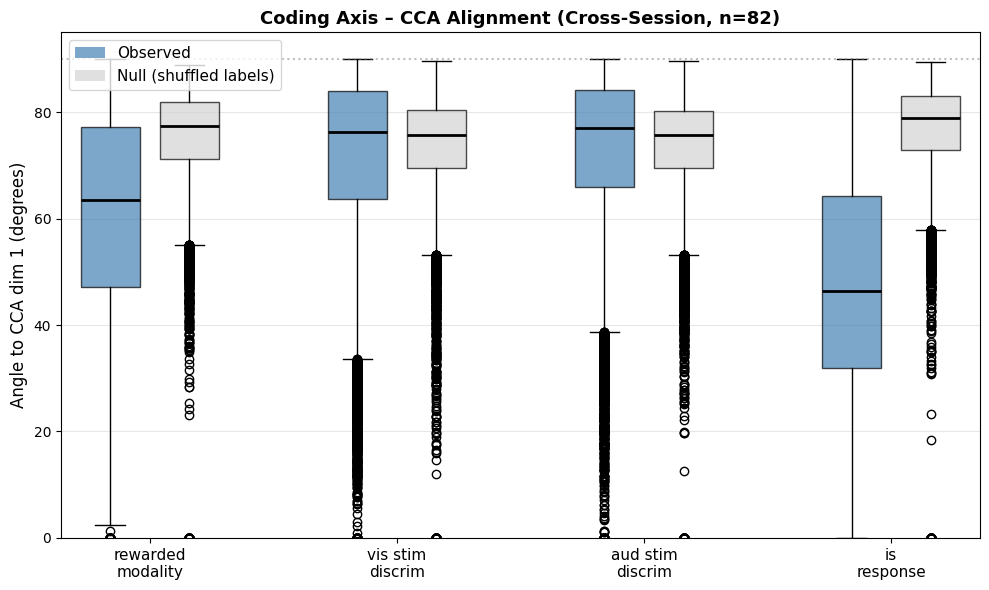

In [39]:
# ── Boxplot: observed angles vs null, grouped by task variable (cross-session) ──
from matplotlib.patches import Patch

var_names = ['rewarded_modality', 'vis_stim_discrim', 'aud_stim_discrim', 'is_response']
var_labels = ['rewarded\nmodality', 'vis stim\ndiscrim', 'aud stim\ndiscrim', 'is\nresponse']

fig, ax = plt.subplots(figsize=(10, 6))

positions_obs = np.arange(len(var_names)) * 2.5
positions_null = positions_obs + 0.8

bp_obs = ax.boxplot(
    [all_angles_df.loc[all_angles_df['variable'] == v, 'observed_angle_deg'].dropna().values
     for v in var_names],
    positions=positions_obs, widths=0.6, patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.7),
    medianprops=dict(color='black', linewidth=2),
)

bp_null = ax.boxplot(
    [all_angles_df.loc[all_angles_df['variable'] == v, 'null_mean_deg'].dropna().values
     for v in var_names],
    positions=positions_null, widths=0.6, patch_artist=True,
    boxprops=dict(facecolor='lightgray', alpha=0.7),
    medianprops=dict(color='black', linewidth=2),
)

ax.set_xticks((positions_obs + positions_null) / 2)
ax.set_xticklabels(var_labels, fontsize=11)
ax.set_ylabel('Angle to CCA dim 1 (degrees)', fontsize=12)
ax.set_title(f'Coding Axis – CCA Alignment (Cross-Session, n={all_angles_df["session_id"].nunique()})',
             fontsize=13, fontweight='bold')
ax.set_ylim([0, 95])
ax.axhline(90, color='gray', linestyle=':', alpha=0.5)
ax.legend(
    [Patch(facecolor='steelblue', alpha=0.7), Patch(facecolor='lightgray', alpha=0.7)],
    ['Observed', 'Null (shuffled labels)'],
    fontsize=11, loc='upper left'
)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

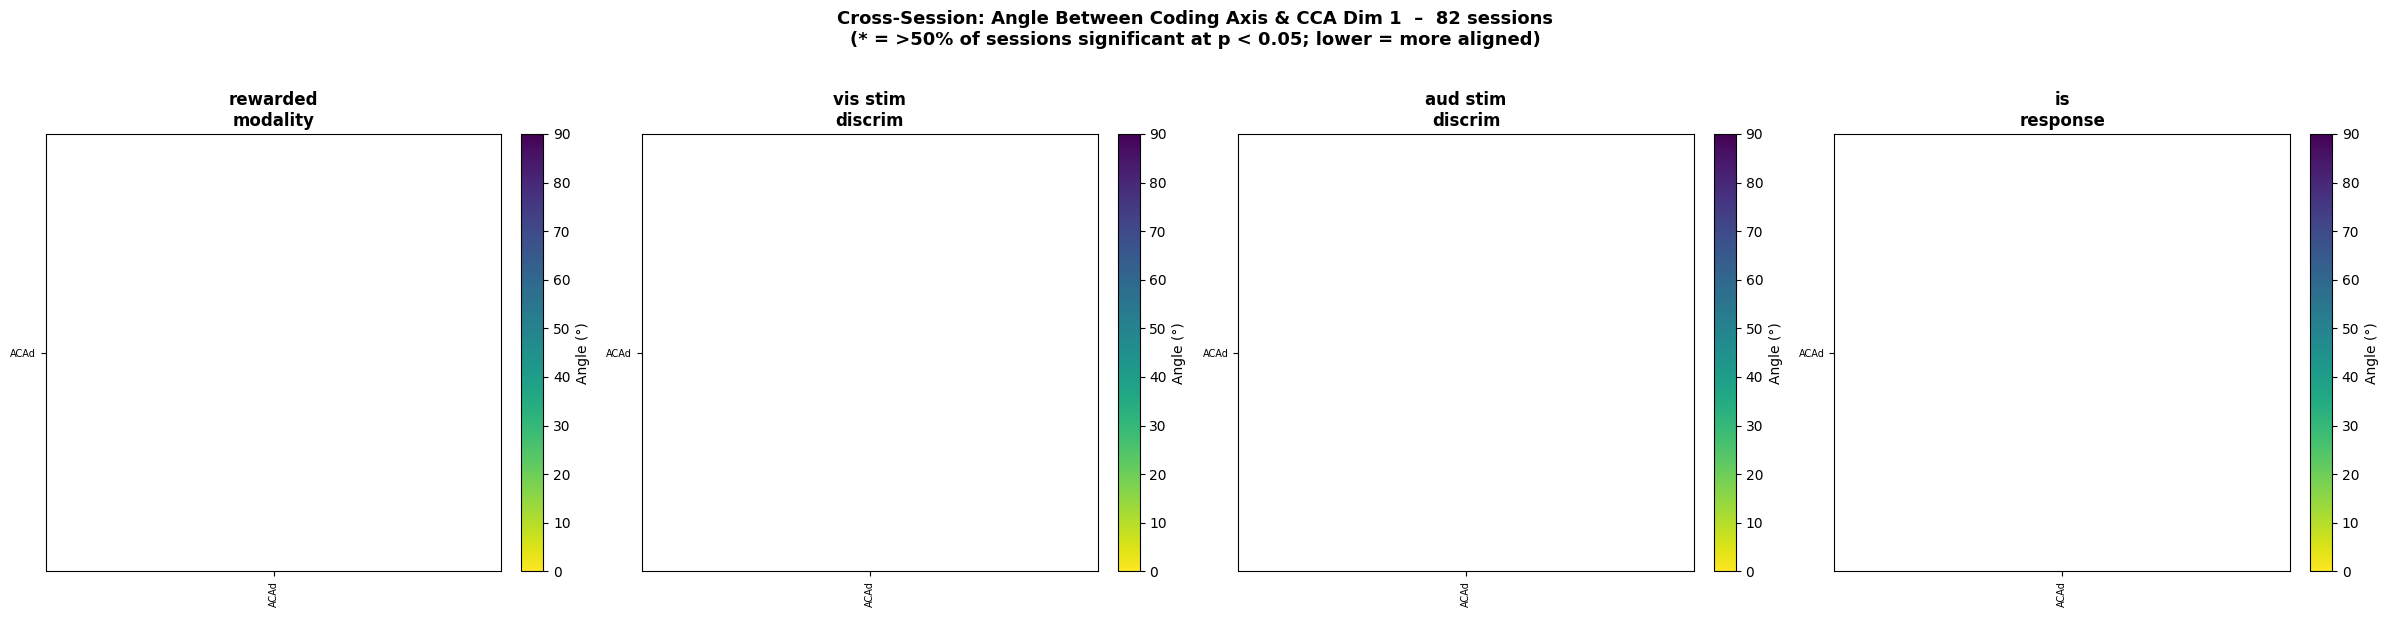

In [40]:
# ── Cross-session heatmaps: angle per (area pair, variable) ────────────────────
# Average over sessions and struct_role to get one value per (pair, variable).
pair_var_cross = (
    all_angles_df
    .groupby(['struct_A', 'struct_B', 'variable'])
    .agg(
        mean_angle=('observed_angle_deg', 'mean'),
        mean_null=('null_mean_deg', 'mean'),
        n_sig=('significant', 'sum'),
        n_total=('significant', 'count'),
        n_sessions=('session_id', 'nunique'),
    )
    .reset_index()
)
pair_var_cross['frac_sig'] = pair_var_cross['n_sig'] / pair_var_cross['n_total']

# Filter to structures with enough data
angle_structs = sorted(
    set(pair_var_cross['struct_A']) | set(pair_var_cross['struct_B'])
)
angle_structs = filter_structs_by_coverage(
    pair_var_cross[pair_var_cross['variable'] == 'rewarded_modality'],
    angle_structs, COVERAGE_THRESH
)

fig, axes = plt.subplots(1, len(var_names), figsize=(6 * len(var_names), 6))

for ax, var_name, var_label in zip(axes, var_names, var_labels):
    sub = pair_var_cross[pair_var_cross['variable'] == var_name]
    mat = build_matrix(sub, 'mean_angle', angle_structs)

    im = ax.imshow(mat, vmin=0, vmax=90, cmap='viridis_r', aspect='auto')
    ax.set_xticks(range(len(angle_structs)))
    ax.set_yticks(range(len(angle_structs)))
    ax.set_xticklabels(angle_structs, rotation=90, fontsize=7)
    ax.set_yticklabels(angle_structs, fontsize=7)
    ax.set_title(var_label, fontsize=12, fontweight='bold')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Angle (°)')

    # Mark pairs where >50% of sessions are significant
    idx_map = {s: i for i, s in enumerate(angle_structs)}
    sig_sub = sub[sub['frac_sig'] > 0.5]
    for _, row in sig_sub.iterrows():
        if row['struct_A'] in idx_map and row['struct_B'] in idx_map:
            i, j = idx_map[row['struct_A']], idx_map[row['struct_B']]
            ax.text(j, i, '*', ha='center', va='center', color='red',
                    fontsize=10, fontweight='bold')

n_sess_angles = all_angles_df['session_id'].nunique()
plt.suptitle(
    f'Cross-Session: Angle Between Coding Axis & CCA Dim 1  –  {n_sess_angles} sessions\n'
    f'(* = >50% of sessions significant at p < 0.05; lower = more aligned)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

ValueError: The number of observations cannot be determined on an empty distance matrix.

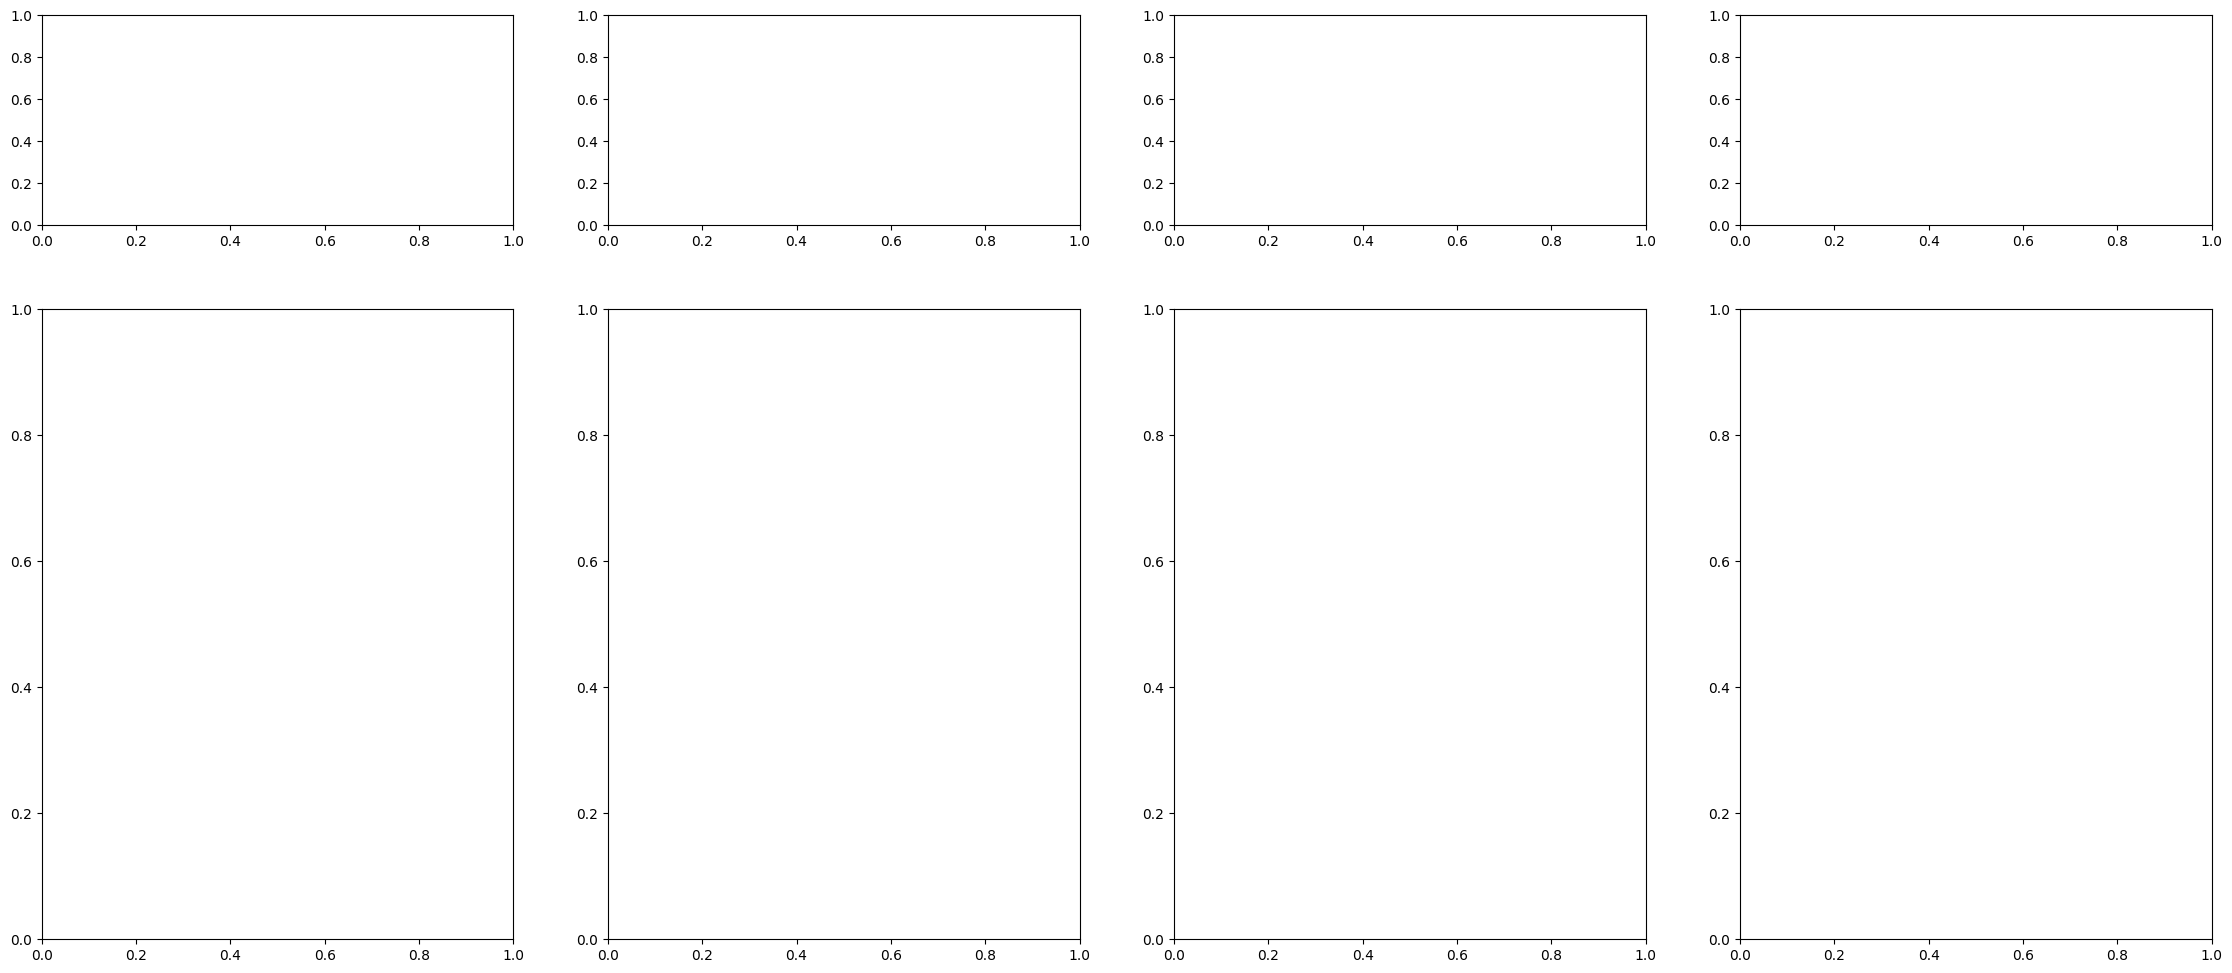

In [41]:
# ── Hierarchically clustered heatmaps per coding axis (cross-session) ──────────
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

n_angle_structs = len(angle_structs)
cluster_assignments_cross = {}

fig, axes = plt.subplots(2, len(var_names), figsize=(7 * len(var_names), 12),
                         gridspec_kw={'height_ratios': [1, 3]})

for col, (var_name, var_label) in enumerate(zip(var_names, var_labels)):
    sub = pair_var_cross[pair_var_cross['variable'] == var_name]
    mat = build_matrix(sub, 'mean_angle', angle_structs)

    np.fill_diagonal(mat, 0)
    mat = np.nan_to_num(mat, nan=90.0)

    condensed = squareform(mat, checks=False)
    Z = linkage(condensed, method='average')

    # Dendrogram (top row)
    ax_dend = axes[0, col]
    dend = dendrogram(Z, labels=angle_structs, ax=ax_dend,
                      leaf_rotation=90, leaf_font_size=8,
                      color_threshold=0.7 * max(Z[:, 2]))
    ax_dend.set_title(var_label, fontsize=12, fontweight='bold')
    ax_dend.set_ylabel('Angle (°)')

    # Reorder matrix
    order = dend['leaves']
    ordered_structs = [angle_structs[i] for i in order]
    mat_ordered = mat[np.ix_(order, order)]

    # Heatmap (bottom row)
    ax_heat = axes[1, col]
    im = ax_heat.imshow(mat_ordered, vmin=0, vmax=90, cmap='viridis_r', aspect='auto')
    ax_heat.set_xticks(range(n_angle_structs))
    ax_heat.set_yticks(range(n_angle_structs))
    ax_heat.set_xticklabels(ordered_structs, rotation=90, fontsize=7)
    ax_heat.set_yticklabels(ordered_structs, fontsize=7)
    fig.colorbar(im, ax=ax_heat, fraction=0.046, pad=0.04, label='Angle (°)')

    # Mark significant pairs
    sig_sub = sub[sub['frac_sig'] > 0.5]
    ordered_idx = {s: i for i, s in enumerate(ordered_structs)}
    for _, row in sig_sub.iterrows():
        if row['struct_A'] in ordered_idx and row['struct_B'] in ordered_idx:
            ri, ci = ordered_idx[row['struct_A']], ordered_idx[row['struct_B']]
            ax_heat.text(ci, ri, '*', ha='center', va='center', color='red',
                         fontsize=9, fontweight='bold')

    # Cluster assignments
    threshold = 0.7 * max(Z[:, 2])
    labels_cl = fcluster(Z, t=threshold, criterion='distance')
    cluster_assignments_cross[var_name] = {s: int(c) for s, c in zip(angle_structs, labels_cl)}

plt.suptitle(
    f'Cross-Session Clustered: Coding Axis – CCA Dim 1 Angle  –  {n_sess_angles} sessions\n'
    f'(* = >50% of sessions sig.; lower = more aligned)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

# Print cluster assignments
for var_name, var_label in zip(var_names, var_labels):
    ca = cluster_assignments_cross[var_name]
    n_cl = len(set(ca.values()))
    print(f"\n{var_label.replace(chr(10),' ')}  ({n_cl} clusters):")
    for cl_id in sorted(set(ca.values())):
        members = [s for s, c in ca.items() if c == cl_id]
        print(f"  Cluster {cl_id}: {', '.join(members)}")

In [ ]:
# ── Compare cluster assignments across coding axes (cross-session) ──────────────
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

cluster_matrix_cross = pd.DataFrame(cluster_assignments_cross, index=angle_structs)
cluster_matrix_cross.columns = [vl.replace('\n', ' ') for vl in var_labels]

print("Cross-session cluster assignments per structure:")
print(cluster_matrix_cross.to_string())

# Pairwise ARI/AMI
ari_records_cross = []
for i, v1 in enumerate(var_names):
    for j, v2 in enumerate(var_names):
        if j <= i:
            continue
        labels1 = [cluster_assignments_cross[v1][s] for s in angle_structs]
        labels2 = [cluster_assignments_cross[v2][s] for s in angle_structs]
        ari = adjusted_rand_score(labels1, labels2)
        ami = adjusted_mutual_info_score(labels1, labels2)
        ari_records_cross.append({
            'axis_1': var_labels[i].replace('\n', ' '),
            'axis_2': var_labels[j].replace('\n', ' '),
            'ARI': round(ari, 3),
            'AMI': round(ami, 3),
        })

ari_df_cross = pd.DataFrame(ari_records_cross)
print("\nPairwise clustering similarity (ARI / AMI):")
print(ari_df_cross.to_string(index=False))

In [ ]:
# ── Best-aligned task variable per area pair (cross-session) ───────────────────
best_files = sorted(output_dir.glob('cca_best_aligned_*.parquet'))
all_best = []
for f in best_files:
    try:
        all_best.append(pd.read_parquet(f))
    except Exception:
        pass

all_best_df = pd.concat(all_best, ignore_index=True)
all_best_df = all_best_df.query('session_id in @dr_session_list_good')

# For each pair, which variable is most often best-aligned across sessions?
best_cross = (
    all_best_df
    .groupby(['struct_A', 'struct_B', 'variable'])
    .agg(count=('session_id', 'count'), mean_angle=('mean_angle', 'mean'))
    .reset_index()
)

# Most frequent best-aligned variable per pair
best_modal = (
    best_cross
    .loc[best_cross.groupby(['struct_A', 'struct_B'])['count'].idxmax()]
    [['struct_A', 'struct_B', 'variable', 'count', 'mean_angle']]
    .sort_values('mean_angle')
    .reset_index(drop=True)
)

print(f"Best-aligned variable (modal across sessions) per area pair:")
print(best_modal.head(20).to_string(index=False))

print(f"\n\nFrequency of best-aligned variable (across all pairs × sessions):")
print(all_best_df['variable'].value_counts().to_string())

In [ ]:
# ── Strip plot: observed angle per variable, with null band (cross-session) ────
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 6))

colors = {'rewarded_modality': '#1f77b4', 'vis_stim_discrim': '#ff7f0e',
          'aud_stim_discrim': '#2ca02c', 'is_response': '#d62728'}

for i, var_name in enumerate(var_names):
    sub = all_angles_df[all_angles_df['variable'] == var_name]
    # Subsample for readability if too many points
    if len(sub) > 500:
        sub_plot = sub.sample(500, random_state=42)
    else:
        sub_plot = sub
    jitter = np.random.uniform(-0.15, 0.15, size=len(sub_plot))

    ax.scatter(
        np.full(len(sub_plot), i) + jitter,
        sub_plot['observed_angle_deg'],
        alpha=0.2, s=10, color=colors[var_name], zorder=3,
    )
    # Null mean ± 1 std band
    null_mean = sub['null_mean_deg'].mean()
    null_std = sub['null_std_deg'].mean()
    ax.fill_between(
        [i - 0.3, i + 0.3], null_mean - null_std, null_mean + null_std,
        color='gray', alpha=0.2, zorder=1,
    )
    ax.hlines(null_mean, i - 0.3, i + 0.3, color='gray', linewidth=2, zorder=2)

    # Median observed
    obs_median = sub['observed_angle_deg'].median()
    ax.hlines(obs_median, i - 0.3, i + 0.3, color=colors[var_name],
              linewidth=3, zorder=4)

ax.set_xticks(range(len(var_names)))
ax.set_xticklabels(var_labels, fontsize=11)
ax.set_ylabel('Angle to CCA dim 1 (degrees)', fontsize=12)
ax.set_title(f'Cross-Session Coding Axis – CCA Alignment\n'
             f'({all_angles_df["session_id"].nunique()} sessions)',
             fontsize=13, fontweight='bold')
ax.set_ylim([0, 95])
ax.axhline(90, color='gray', linestyle=':', alpha=0.4)
ax.grid(axis='y', alpha=0.3)

legend_elems = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markersize=6, label='Individual observation'),
    Line2D([0], [0], color='gray', linewidth=2, label='Null mean'),
    Patch(facecolor='gray', alpha=0.2, label='Null ± 1 SD'),
    Line2D([0], [0], color='black', linewidth=3, label='Median observed'),
]
ax.legend(handles=legend_elems, fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# ── Per-structure summary: which variables align with CCA across areas? ─────────
# For each structure, average the observed angle across all pairs it participates in.
struct_var_summary = (
    all_angles_df
    .groupby(['structure', 'variable'])
    .agg(
        mean_angle=('observed_angle_deg', 'mean'),
        mean_null=('null_mean_deg', 'mean'),
        frac_sig=('significant', 'mean'),
        n_obs=('significant', 'count'),
    )
    .reset_index()
)

# Pivot for heatmap
pivot_angle = struct_var_summary.pivot(index='structure', columns='variable', values='mean_angle')
pivot_sig = struct_var_summary.pivot(index='structure', columns='variable', values='frac_sig')

# Filter to well-represented structures
struct_counts = struct_var_summary.groupby('structure')['n_obs'].sum()
good_structs = struct_counts[struct_counts >= 20].index.tolist()
pivot_angle = pivot_angle.loc[pivot_angle.index.isin(good_structs)]
pivot_sig = pivot_sig.loc[pivot_sig.index.isin(good_structs)]

# Sort by mean angle across all variables
pivot_angle = pivot_angle.loc[pivot_angle.mean(axis=1).sort_values().index]
pivot_sig = pivot_sig.reindex(pivot_angle.index)

fig, ax = plt.subplots(figsize=(8, max(6, len(pivot_angle) * 0.35)))
im = ax.imshow(pivot_angle.values, vmin=0, vmax=90, cmap='viridis_r', aspect='auto')
ax.set_xticks(range(len(var_names)))
ax.set_yticks(range(len(pivot_angle)))
ax.set_xticklabels([vl.replace('\n', ' ') for vl in var_labels], fontsize=10)
ax.set_yticklabels(pivot_angle.index, fontsize=8)
ax.set_title(f'Per-Structure Mean Angle to CCA Dim 1 (Cross-Session)\n'
             f'(* = >50% sessions significant)', fontsize=12, fontweight='bold')
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04, label='Angle (°)')

# Mark high-significance cells
for yi, struct in enumerate(pivot_angle.index):
    for xi, var in enumerate(pivot_angle.columns):
        if pivot_sig.loc[struct, var] > 0.5:
            ax.text(xi, yi, '*', ha='center', va='center', color='red',
                    fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()